In [1]:
import numpy as np
import pandas as pd
import math as math
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib as matplotlib
import scipy as scipy
import shutil

import subprocess
import os
import scipy.stats as stats
from collections import Counter

import seaborn as sns

np.__version__, matplotlib.__version__, scipy.__version__,  pd.__version__, sns.__version__

('1.26.4', '3.9.2', '1.13.1', '2.2.2', '0.13.2')

In [2]:
plt.rcParams["font.sans-serif"]='Arial'

In [3]:
def get_derivative_growth_rate(well, df, tmax=18):
    # well : a tuple of the format (row, col)
    # source : DataFrame where well was measured
    # tmax : defines the interval in which the function will measure the growth rate, from t=0 to t=tmax
    
    df_cols = [ x for x in list(df.index) if x<=tmax]
    # define time range
    
    df_data = df.loc[df_cols]
    # select the subset of the DataFrame in the selected timerange
    data = df_data[(well[0]+str(well[1]))]
    # 

    data_diff = data.diff()*3
    # one measurement every 20 mins instead of 15
    
    get_top_5 = data_diff.nlargest(5)
    
    growth_rate = np.median(get_top_5)
    std_err = np.std(get_top_5)
    
    return growth_rate, std_err

In [4]:
def get_growth_rate_dict(df):
    
    growth_rate_dict = {}
    
    for well in list(df.columns):
    
        row = well[0]
        col = int(well[1:])

        growth_rate = get_derivative_growth_rate((row, col), df, tmax=18)

        growth_rate_dict[well] = growth_rate[0]
        
    return growth_rate_dict
            

In [5]:
def get_AUC(well, df, t_end = 18):
    
    df_indexes = [ x for x in list(df.index) if x<=t_end]
    
    #print(well)
    
    df_data = df.loc[df_indexes]
    data = df_data[well]
       
    x_vals = list(data.index)
    y_vals = [data.loc[x] for x in list(data.index)]
    
    auc = np.trapz(y_vals, x=x_vals)
    
    return auc

In [6]:
def get_AUC_dict(df):
    
    AUC_dict = {}
    
    for well in list(df.columns):
    
        AUC_dict[well] = get_AUC(well, df)
        
    return AUC_dict

# Inducible promoter test KSP1

In [7]:
qpcr_KSP1_df = pd.read_excel('./qPCR/Inducible_prom_test.xlsx')
qpcr_KSP1_df

,strain,rep,ACT1,dCas9,KSP1
0,187,1,16.206306,20.512216,20.924430
1,187,2,17.066510,20.689342,20.921613
2,187,3,16.671557,20.633904,21.106431
3,584,1,16.740053,20.945798,21.088122
4,584,2,16.623673,20.884761,20.783610
5,584,3,16.562802,20.745936,20.986074
6,692,1,16.697182,20.951005,23.449515
7,692,2,16.779930,21.329430,23.729700
8,692,3,16.810673,20.771835,23.639312
9,756,1,16.721164,20.849498,23.563261


In [8]:
baseline_ACT1 = qpcr_KSP1_df.loc[[0,1,2]]['ACT1'].mean()
baseline_KSP1 = qpcr_KSP1_df.loc[[0,1,2]]['KSP1'].mean()
baseline_dCas9 = qpcr_KSP1_df.loc[[0,1,2]]['dCas9'].mean()
baseline_ACT1, baseline_KSP1, baseline_dCas9

(16.648124383333332, 20.984158266666665, 20.61182042333333)

In [9]:
deltaATC1_ctrl = baseline_KSP1-baseline_ACT1
deltaATC1_ctrl

4.336033883333332

In [10]:
qpcr_KSP1_df['deltaKSP1'] =  qpcr_KSP1_df['KSP1'] - qpcr_KSP1_df['ACT1']
qpcr_KSP1_df

,strain,rep,ACT1,dCas9,KSP1,deltaKSP1
0,187,1,16.206306,20.512216,20.924430,4.718124
1,187,2,17.066510,20.689342,20.921613,3.855103
2,187,3,16.671557,20.633904,21.106431,4.434874
3,584,1,16.740053,20.945798,21.088122,4.348069
4,584,2,16.623673,20.884761,20.783610,4.159938
5,584,3,16.562802,20.745936,20.986074,4.423271
6,692,1,16.697182,20.951005,23.449515,6.752333
7,692,2,16.779930,21.329430,23.729700,6.949770
8,692,3,16.810673,20.771835,23.639312,6.828639
9,756,1,16.721164,20.849498,23.563261,6.842097


In [11]:
qpcr_KSP1_df['deltadeltaKSP1'] = qpcr_KSP1_df['deltaKSP1']-deltaATC1_ctrl

qpcr_KSP1_df

,strain,rep,ACT1,dCas9,KSP1,deltaKSP1,deltadeltaKSP1
0,187,1,16.206306,20.512216,20.924430,4.718124,0.382090
1,187,2,17.066510,20.689342,20.921613,3.855103,-0.480931
2,187,3,16.671557,20.633904,21.106431,4.434874,0.098841
3,584,1,16.740053,20.945798,21.088122,4.348069,0.012035
4,584,2,16.623673,20.884761,20.783610,4.159938,-0.176096
5,584,3,16.562802,20.745936,20.986074,4.423271,0.087237
6,692,1,16.697182,20.951005,23.449515,6.752333,2.416299
7,692,2,16.779930,21.329430,23.729700,6.949770,2.613736
8,692,3,16.810673,20.771835,23.639312,6.828639,2.492605
9,756,1,16.721164,20.849498,23.563261,6.842097,2.506063


In [12]:
qpcr_KSP1_df['KSP1_fold_repression'] = 2**qpcr_KSP1_df['deltadeltaKSP1']
qpcr_KSP1_df

,strain,rep,ACT1,dCas9,KSP1,deltaKSP1,deltadeltaKSP1,KSP1_fold_repression
0,187,1,16.206306,20.512216,20.924430,4.718124,0.382090,1.303229
1,187,2,17.066510,20.689342,20.921613,3.855103,-0.480931,0.716515
2,187,3,16.671557,20.633904,21.106431,4.434874,0.098841,1.070912
3,584,1,16.740053,20.945798,21.088122,4.348069,0.012035,1.008377
4,584,2,16.623673,20.884761,20.783610,4.159938,-0.176096,0.885095
5,584,3,16.562802,20.745936,20.986074,4.423271,0.087237,1.062334
6,692,1,16.697182,20.951005,23.449515,6.752333,2.416299,5.338000
7,692,2,16.779930,21.329430,23.729700,6.949770,2.613736,6.120869
8,692,3,16.810673,20.771835,23.639312,6.828639,2.492605,5.627932
9,756,1,16.721164,20.849498,23.563261,6.842097,2.506063,5.680679


In [123]:
mean_list = list(qpcr_KSP1_df.groupby(['strain'])['KSP1_fold_repression'].mean())

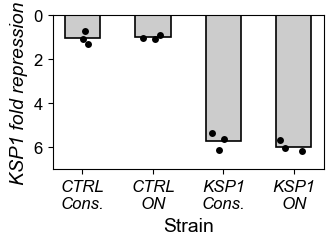

In [124]:
plt.figure(figsize=(3.5, 2))

sns.stripplot(data=qpcr_KSP1_df, x='strain', y='KSP1_fold_repression', color='k', jitter=0.2)

plt.bar([0,1,2,3], mean_list, color='#ccccccff', edgecolor='k', linewidth=1.2,width=0.5)

plt.yticks(fontsize=12)

plt.ylim(7,0)

plt.xticks([0,1,2,3], ['CTRL\nCons.','CTRL\nON','KSP1\nCons.','KSP1\nON'], fontsize=12, style='italic')
plt.xlabel('Strain', fontsize=14)
plt.ylabel('KSP1 fold repression', fontsize=14, style='italic')

plt.savefig('./figures/inducible_prom_test.svg', format='svg', dpi=300)

In [125]:
ctrl_cons_vals = qpcr_KSP1_df[qpcr_KSP1_df['strain']==187]['KSP1_fold_repression']
ctrl_ON_vals = qpcr_KSP1_df[qpcr_KSP1_df['strain']==584]['KSP1_fold_repression']

KSP1_cons_vals = qpcr_KSP1_df[qpcr_KSP1_df['strain']==692]['KSP1_fold_repression']
KSP1_ON_vals = qpcr_KSP1_df[qpcr_KSP1_df['strain']==756]['KSP1_fold_repression']

ctrl_cons_vals
print('ctrl cons vs ctrl ON', scipy.stats.ttest_ind(ctrl_cons_vals, ctrl_ON_vals, equal_var=False))
print('ctrl cons vs KSP1 cons', scipy.stats.ttest_ind(ctrl_cons_vals, KSP1_cons_vals, equal_var=False))
print('ctrl ON vs KSP1 ON', scipy.stats.ttest_ind(ctrl_ON_vals, KSP1_ON_vals, equal_var=False))
print('KSP1 cons vs KSP1 ON', scipy.stats.ttest_ind(KSP1_cons_vals, KSP1_ON_vals, equal_var=False))

ctrl cons vs ctrl ON TtestResult(statistic=0.25186531996918093, pvalue=0.8213081643910767, df=2.3748361424101163)
ctrl cons vs KSP1 cons TtestResult(statistic=-16.36036000874658, pvalue=0.00013778048453441823, df=3.700884435588926)
ctrl ON vs KSP1 ON TtestResult(statistic=-31.891832959146925, pvalue=0.00024959140502279847, df=2.500430582099129)
KSP1 cons vs KSP1 ON TtestResult(statistic=-0.9957909862504583, pvalue=0.38457851952982086, df=3.414780259886208)


# Inducible promoter test HSP90


In [126]:
wt_HSP90_plate_ref = pd.read_excel('./Growth_curve_data/plate_map_HSP90_ATC.xlsx', index_col=0)
wt_HSP90_plate_ref

,strain,Preculture,ATC,biological_replicate,technical_replicate
well,,,,,
A1,Blank,NaN,NaN,NaN,NaN
A2,Blank,NaN,NaN,NaN,NaN
A3,Blank,NaN,NaN,NaN,NaN
A4,Blank,NaN,NaN,NaN,NaN
A5,Blank,NaN,NaN,NaN,NaN
...,...,...,...,...,...
H8,Blank,NaN,NaN,NaN,NaN
H9,Blank,NaN,NaN,NaN,NaN
H10,Blank,NaN,NaN,NaN,NaN


In [127]:
wt_HSP90_data = pd.read_excel('./Growth_curve_data/raw_data_HSP90_ATC_test.xlsx', index_col=0).T
wt_HSP90_data

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,H3,H4,H5,H6,H7,H8,H9,H10,H11,H12
0.000000,0.1508,0.1490,0.1582,0.1578,0.1556,0.1591,0.1619,0.1733,0.1691,0.1687,...,0.1040,0.1147,0.1281,0.1299,0.1258,0.1330,0.1331,0.1264,0.1251,0.1006
0.333333,0.0994,0.0999,0.1002,0.1003,0.1012,0.1011,0.1008,0.1013,0.1009,0.1010,...,0.0991,0.0996,0.0986,0.0992,0.0987,0.0998,0.0998,0.0997,0.1002,0.1020
0.666667,0.0993,0.0998,0.1000,0.1001,0.1010,0.1009,0.1006,0.1011,0.1006,0.1007,...,0.0988,0.0992,0.0982,0.0988,0.0984,0.0994,0.0993,0.0994,0.0999,0.1017
1.000000,0.0993,0.0998,0.1000,0.1001,0.1010,0.1010,0.1007,0.1012,0.1007,0.1008,...,0.0991,0.0995,0.0985,0.0991,0.0986,0.0997,0.0997,0.0997,0.1002,0.1020
1.333333,0.0993,0.0998,0.1000,0.1001,0.1011,0.1010,0.1007,0.1012,0.1007,0.1009,...,0.0995,0.1000,0.0989,0.0996,0.0990,0.1001,0.1001,0.1002,0.1006,0.1025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22.666667,0.1001,0.1005,0.1007,0.1006,0.1011,0.1005,0.1008,0.1008,0.1004,0.1005,...,0.1003,0.1007,0.0996,0.1003,0.0999,0.1007,0.1012,0.1012,0.1013,0.1035
23.000000,0.1000,0.1005,0.1007,0.1007,0.1010,0.1005,0.1007,0.1007,0.1003,0.1004,...,0.1003,0.1006,0.0996,0.1002,0.0998,0.1008,0.1012,0.1012,0.1013,0.1035
23.333333,0.1000,0.1005,0.1007,0.1006,0.1011,0.1005,0.1007,0.1007,0.1003,0.1004,...,0.0998,0.1001,0.0991,0.0997,0.0994,0.1003,0.1007,0.1007,0.1009,0.1030
23.666667,0.1000,0.1006,0.1007,0.1006,0.1011,0.1005,0.1008,0.1007,0.1004,0.1005,...,0.0993,0.0996,0.0988,0.0993,0.0989,0.0998,0.1003,0.1003,0.1004,0.1025


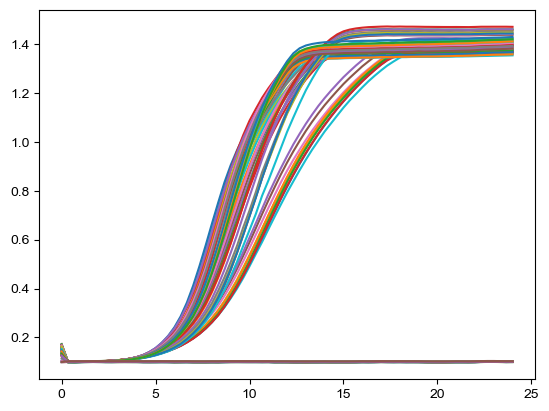

In [128]:
for well in wt_HSP90_data.columns:
    plt.plot(wt_HSP90_data[well])

## qPCR data

In [129]:
qpcr_HSP90_WT_df = pd.read_excel('./qPCR/HSP90_wt_induction_test.xlsx')
qpcr_HSP90_WT_df

,strain,rep,Cq_ACT1_dcas9,Cq_dCas9,Cq_ACT1_HSP90,Cq_HSP90
0,584_ATC,1,14.117606,22.428249,14.527951,16.003219
1,584_ATC,2,14.330639,22.586923,14.387549,15.716133
2,584_ATC,3,14.058467,22.327348,14.631623,15.852516
3,584,1,13.771452,18.253520,14.199846,15.729305
4,584,2,13.343841,17.664049,14.056646,15.466947
5,584,3,13.497725,17.553431,13.796012,15.225028
6,583_ATC,1,13.676531,22.144651,13.944948,16.285729
7,583_ATC,2,13.065204,20.859413,13.596903,15.510098
8,583_ATC,3,13.422952,21.715652,13.742700,15.857910
9,583,1,13.268464,18.165101,13.728056,18.463802


In [130]:
baseline_ACT1_HSP90 = qpcr_HSP90_WT_df.loc[[0,1,2]]['Cq_ACT1_HSP90'].mean()
baseline_HSP90 = qpcr_HSP90_WT_df.loc[[0,1,2]]['Cq_HSP90'].mean()

baseline_ACT1_HSP90, baseline_HSP90

(14.515707486666665, 15.857289043333333)

In [131]:
deltaATC1_ctrl_HSP90 = baseline_HSP90-baseline_ACT1_HSP90
deltaATC1_ctrl_HSP90

1.341581556666668

In [132]:
qpcr_HSP90_WT_df['deltaHSP90'] =  qpcr_HSP90_WT_df['Cq_HSP90'] - qpcr_HSP90_WT_df['Cq_ACT1_HSP90']
qpcr_HSP90_WT_df

,strain,rep,Cq_ACT1_dcas9,Cq_dCas9,Cq_ACT1_HSP90,Cq_HSP90,deltaHSP90
0,584_ATC,1,14.117606,22.428249,14.527951,16.003219,1.475268
1,584_ATC,2,14.330639,22.586923,14.387549,15.716133,1.328584
2,584_ATC,3,14.058467,22.327348,14.631623,15.852516,1.220893
3,584,1,13.771452,18.253520,14.199846,15.729305,1.529459
4,584,2,13.343841,17.664049,14.056646,15.466947,1.410301
5,584,3,13.497725,17.553431,13.796012,15.225028,1.429016
6,583_ATC,1,13.676531,22.144651,13.944948,16.285729,2.340780
7,583_ATC,2,13.065204,20.859413,13.596903,15.510098,1.913195
8,583_ATC,3,13.422952,21.715652,13.742700,15.857910,2.115210
9,583,1,13.268464,18.165101,13.728056,18.463802,4.735746


In [133]:
qpcr_HSP90_WT_df['deltadeltaHSP90'] = qpcr_HSP90_WT_df['deltaHSP90']-deltaATC1_ctrl_HSP90

qpcr_HSP90_WT_df

,strain,rep,Cq_ACT1_dcas9,Cq_dCas9,Cq_ACT1_HSP90,Cq_HSP90,deltaHSP90,deltadeltaHSP90
0,584_ATC,1,14.117606,22.428249,14.527951,16.003219,1.475268,0.133686
1,584_ATC,2,14.330639,22.586923,14.387549,15.716133,1.328584,-0.012997
2,584_ATC,3,14.058467,22.327348,14.631623,15.852516,1.220893,-0.120689
3,584,1,13.771452,18.253520,14.199846,15.729305,1.529459,0.187878
4,584,2,13.343841,17.664049,14.056646,15.466947,1.410301,0.068719
5,584,3,13.497725,17.553431,13.796012,15.225028,1.429016,0.087435
6,583_ATC,1,13.676531,22.144651,13.944948,16.285729,2.340780,0.999199
7,583_ATC,2,13.065204,20.859413,13.596903,15.510098,1.913195,0.571614
8,583_ATC,3,13.422952,21.715652,13.742700,15.857910,2.115210,0.773629
9,583,1,13.268464,18.165101,13.728056,18.463802,4.735746,3.394165


In [134]:
qpcr_HSP90_WT_df['HSP90_fold_repression'] = 2**qpcr_HSP90_WT_df['deltadeltaHSP90']
qpcr_HSP90_WT_df

,strain,rep,Cq_ACT1_dcas9,Cq_dCas9,Cq_ACT1_HSP90,Cq_HSP90,deltaHSP90,deltadeltaHSP90,HSP90_fold_repression
0,584_ATC,1,14.117606,22.428249,14.527951,16.003219,1.475268,0.133686,1.097093
1,584_ATC,2,14.330639,22.586923,14.387549,15.716133,1.328584,-0.012997,0.991031
2,584_ATC,3,14.058467,22.327348,14.631623,15.852516,1.220893,-0.120689,0.919748
3,584,1,13.771452,18.253520,14.199846,15.729305,1.529459,0.187878,1.139087
4,584,2,13.343841,17.664049,14.056646,15.466947,1.410301,0.068719,1.048785
5,584,3,13.497725,17.553431,13.796012,15.225028,1.429016,0.087435,1.062479
6,583_ATC,1,13.676531,22.144651,13.944948,16.285729,2.340780,0.999199,1.998890
7,583_ATC,2,13.065204,20.859413,13.596903,15.510098,1.913195,0.571614,1.486185
8,583_ATC,3,13.422952,21.715652,13.742700,15.857910,2.115210,0.773629,1.709564
9,583,1,13.268464,18.165101,13.728056,18.463802,4.735746,3.394165,10.513452


In [135]:
mean_list = list(qpcr_HSP90_WT_df.groupby(['strain'],sort=False)['HSP90_fold_repression'].mean())

In [136]:
mean_list

[1.002624349125518, 1.0834503841831076, 1.7315463825519448, 10.178975550400112]

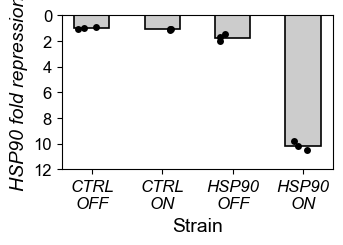

In [137]:
plt.figure(figsize=(3.5, 2))

sns.stripplot(data=qpcr_HSP90_WT_df, x='strain', y='HSP90_fold_repression', color='k', jitter=0.2)

plt.bar([0,1,2,3], mean_list, color='#ccccccff', edgecolor='k', linewidth=1.2,width=0.5)


plt.ylim(12,0)

plt.xticks([0,1,2,3], ['CTRL\nOFF','CTRL\nON','HSP90\nOFF','HSP90\nON'], fontsize=12, style='italic')
plt.xlabel('Strain', fontsize=14)
plt.ylabel('HSP90 fold repression', fontsize=14, style='italic')
plt.yticks([0,2,4,6,8,10,12],fontsize=12)

plt.savefig('./figures/inducible_prom_test_HSP90.svg', format='svg', dpi=300)

In [28]:
ctrl_OFF_vals = qpcr_HSP90_WT_df[qpcr_HSP90_WT_df['strain']=='584_ATC']['HSP90_fold_repression']
ctrl_ON_vals = qpcr_HSP90_WT_df[qpcr_HSP90_WT_df['strain']==584]['HSP90_fold_repression']

HSP90_OFF_vals = qpcr_HSP90_WT_df[qpcr_HSP90_WT_df['strain']=='583_ATC']['HSP90_fold_repression']
HSP90_ON_vals = qpcr_HSP90_WT_df[qpcr_HSP90_WT_df['strain']==583]['HSP90_fold_repression']

ctrl_cons_vals
print('ctrl OFF vs ctrl ON', scipy.stats.ttest_ind(ctrl_OFF_vals, ctrl_ON_vals, equal_var=False))
print('ctrl OFF vs HSP90 OFF', scipy.stats.ttest_ind(ctrl_OFF_vals, HSP90_OFF_vals, equal_var=False))
print('ctrl OFF vs HSP90 ON', scipy.stats.ttest_ind(ctrl_OFF_vals, HSP90_ON_vals, equal_var=False))


ctrl OFF vs ctrl ON TtestResult(statistic=-1.37726981851195, pvalue=0.25964762536137787, df=3.0929602680223773)
ctrl OFF vs HSP90 OFF TtestResult(statistic=-4.639820928928263, pvalue=0.028452620287637995, df=2.4751642677978007)
ctrl OFF vs HSP90 ON TtestResult(statistic=-44.584251562882095, pvalue=0.00022001249590748476, df=2.2662184600267636)


In [29]:
10/1.7

5.882352941176471

In [30]:
wt_HSP90_plate_ref

,strain,Preculture,ATC,biological_replicate,technical_replicate
well,,,,,
A1,Blank,NaN,NaN,NaN,NaN
A2,Blank,NaN,NaN,NaN,NaN
A3,Blank,NaN,NaN,NaN,NaN
A4,Blank,NaN,NaN,NaN,NaN
A5,Blank,NaN,NaN,NaN,NaN
...,...,...,...,...,...
H8,Blank,NaN,NaN,NaN,NaN
H9,Blank,NaN,NaN,NaN,NaN
H10,Blank,NaN,NaN,NaN,NaN


In [31]:
growth_rate_dict_wt_HSP90 = get_growth_rate_dict(wt_HSP90_data)
get_AUC_dict_wt_HSP90 = get_AUC_dict(wt_HSP90_data)

wt_HSP90_plate_ref['growth_rate'] = pd.Series(growth_rate_dict_wt_HSP90)
wt_HSP90_plate_ref['AUC'] = pd.Series(get_AUC_dict_wt_HSP90)

In [32]:
wt_HSP90_blanks = wt_HSP90_plate_ref['strain']=='Blank'
wt_HSP90_plate_ref[~wt_HSP90_blanks]

,strain,Preculture,ATC,biological_replicate,technical_replicate,growth_rate,AUC
well,,,,,,,
B2,WT_CTRL,YPD,YPD,1.0,1.0,0.2556,12.872100
B3,WT_CTRL,YPD,YPD,1.0,2.0,0.2448,12.939850
B4,WT_CTRL,YPD,YPD,1.0,3.0,0.2550,12.761533
B5,WT_CTRL,YPD,YPD,1.0,4.0,0.2559,12.901050
B6,WT_CTRL,YPD,YPD,1.0,5.0,0.2526,13.071917
B7,WT_CTRL,YPD,YPD,2.0,1.0,0.2619,13.052700
B8,WT_CTRL,YPD,YPD,2.0,2.0,0.2406,12.745533
B9,WT_CTRL,YPD,YPD,2.0,3.0,0.2649,13.036250
B10,WT_CTRL,YPD,YPD,2.0,4.0,0.2565,13.006017


In [33]:
wt_HSP90_blank_median = wt_HSP90_plate_ref[wt_HSP90_blanks]['AUC'].median()
wt_HSP90_plate_ref['adjusted_AUC'] = wt_HSP90_plate_ref['AUC']-wt_HSP90_blank_median

wt_HSP90_plate_ref['plot_group'] = wt_HSP90_plate_ref['strain'] + '_' + wt_HSP90_plate_ref['Preculture'] + '_' + wt_HSP90_plate_ref['ATC']

wt_HSP90_plate_ref

,strain,Preculture,ATC,biological_replicate,technical_replicate,growth_rate,AUC,adjusted_AUC,plot_group
well,,,,,,,,,
A1,Blank,NaN,NaN,NaN,NaN,0.0003,1.772017,-0.006542,NaN
A2,Blank,NaN,NaN,NaN,NaN,0.0003,1.776550,-0.002008,NaN
A3,Blank,NaN,NaN,NaN,NaN,0.0003,1.779917,0.001358,NaN
A4,Blank,NaN,NaN,NaN,NaN,0.0003,1.781833,0.003275,NaN
A5,Blank,NaN,NaN,NaN,NaN,0.0003,1.795133,0.016575,NaN
...,...,...,...,...,...,...,...,...,...
H8,Blank,NaN,NaN,NaN,NaN,0.0012,1.762383,-0.016175,NaN
H9,Blank,NaN,NaN,NaN,NaN,0.0012,1.766200,-0.012358,NaN
H10,Blank,NaN,NaN,NaN,NaN,0.0015,1.765017,-0.013542,NaN


In [34]:
wells_for_plot = [ x for x in list(wt_HSP90_plate_ref.index) if x[0] in ['B', 'C', 'D', 'E']]
wt_HSP90_plate_ref.loc[wells_for_plot][~wt_HSP90_blanks]

/tmp/ipykernel_2757/2842630129.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  wt_HSP90_plate_ref.loc[wells_for_plot][~wt_HSP90_blanks]


,strain,Preculture,ATC,biological_replicate,technical_replicate,growth_rate,AUC,adjusted_AUC,plot_group
well,,,,,,,,,
B2,WT_CTRL,YPD,YPD,1.0,1.0,0.2556,12.872100,11.093542,WT_CTRL_YPD_YPD
B3,WT_CTRL,YPD,YPD,1.0,2.0,0.2448,12.939850,11.161292,WT_CTRL_YPD_YPD
B4,WT_CTRL,YPD,YPD,1.0,3.0,0.2550,12.761533,10.982975,WT_CTRL_YPD_YPD
B5,WT_CTRL,YPD,YPD,1.0,4.0,0.2559,12.901050,11.122492,WT_CTRL_YPD_YPD
B6,WT_CTRL,YPD,YPD,1.0,5.0,0.2526,13.071917,11.293358,WT_CTRL_YPD_YPD
B7,WT_CTRL,YPD,YPD,2.0,1.0,0.2619,13.052700,11.274142,WT_CTRL_YPD_YPD
B8,WT_CTRL,YPD,YPD,2.0,2.0,0.2406,12.745533,10.966975,WT_CTRL_YPD_YPD
B9,WT_CTRL,YPD,YPD,2.0,3.0,0.2649,13.036250,11.257692,WT_CTRL_YPD_YPD
B10,WT_CTRL,YPD,YPD,2.0,4.0,0.2565,13.006017,11.227458,WT_CTRL_YPD_YPD


In [35]:
HSP90_induc_err_plot_dict_of_dict = {}


index=0

for group in ['WT_CTRL_YPD_YPD', 'CRISPRi-HSP90_YPD_YPD',
       'CRISPRi-HSP90_ATC_ATC_YPD', 'WT_CTRL_YPD_YPD_ATC']:
    for biorep in [1,2]:
        val_dict={}
        df_slice = wt_HSP90_plate_ref[(wt_HSP90_plate_ref['plot_group']==group)&(wt_HSP90_plate_ref['biological_replicate']==biorep)]
    
        auc_vals = list(df_slice['adjusted_AUC'])
    
        val_dict['group'] = group+''+str(biorep)
        val_dict['mean'] = np.mean(auc_vals)
        val_dict['err_95'] = np.mean(auc_vals) - stats.t.interval(0.95, len(auc_vals)-1, loc=np.mean(auc_vals), scale=stats.sem(auc_vals))[0]
    
        HSP90_induc_err_plot_dict_of_dict[index] = val_dict
        index+=1
HSP90_induc_err_plot_dict_of_dict

{0: {'group': 'WT_CTRL_YPD_YPD1',
  'mean': 11.130731643239665,
  'err_95': 0.13974153347289864},
 1: {'group': 'WT_CTRL_YPD_YPD2',
  'mean': 11.1835716555516,
  'err_95': 0.15533361578597038},
 2: {'group': 'CRISPRi-HSP90_YPD_YPD1',
  'mean': 8.100791699687642,
  'err_95': 0.452751828253815},
 3: {'group': 'CRISPRi-HSP90_YPD_YPD2',
  'mean': 8.064475000898046,
  'err_95': 0.5370525265817214},
 4: {'group': 'CRISPRi-HSP90_ATC_ATC_YPD1',
  'mean': 10.85495832264424,
  'err_95': 0.23716780530606485},
 5: {'group': 'CRISPRi-HSP90_ATC_ATC_YPD2',
  'mean': 10.410938363273946,
  'err_95': 0.2592209724233623},
 6: {'group': 'WT_CTRL_YPD_YPD_ATC1',
  'mean': 11.389274987578398,
  'err_95': 0.1619884447289497},
 7: {'group': 'WT_CTRL_YPD_YPD_ATC2',
  'mean': 11.433114994565653,
  'err_95': 0.05255185240186222}}

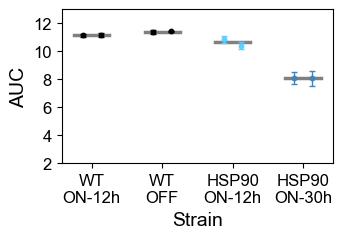

In [36]:
plt.figure(figsize=(3.5,2))


plot_index=1

color_list = ['k', 'k', '#4682B4', '#4682B4', '#63ccffff', '#63ccffff', 'k', 'k', ]

for x in [0,1,6,7,4,5,2,3]:
    plt.scatter(plot_index, HSP90_induc_err_plot_dict_of_dict[x]['mean'], color=color_list[x], s=10, zorder=9)
    plt.errorbar(plot_index, HSP90_induc_err_plot_dict_of_dict[x]['mean'], HSP90_induc_err_plot_dict_of_dict[x]['err_95'], color=color_list[x], elinewidth=1, capsize=2, zorder=9)
    plot_index+=1
    if x%2:
        mean = np.mean([HSP90_induc_err_plot_dict_of_dict[x-1]['mean'], HSP90_induc_err_plot_dict_of_dict[x]['mean']])
        plt.plot([plot_index-2.5, plot_index-0.5], [mean, mean], color='grey', lw=2.5)

#        if x >1:
#            wt_vals = [HSP90_induc_err_plot_dict_of_dict[0]['mean'], HSP90_induc_err_plot_dict_of_dict[1]['mean']]
#            test_val = [HSP90_induc_err_plot_dict_of_dict[x]['mean'], HSP90_induc_err_plot_dict_of_dict[x-1]['mean']]
#            print(wt_vals, test_val)
#            print(scipy.stats.ttest_ind(wt_vals, test_val, equal_var=False)[1])#

#            stat, pval = scipy.stats.ttest_ind(wt_vals, test_val, equal_var=False)
#            if pval < 0.05:
#                print(test_val, pval)
#                plt.plot([plot_index-1.5], [mean+1], marker='$*$', color='k', ms=5)
        
#        print(x)
        plot_index+=2


plt.ylabel('AUC', fontsize=14)
plt.xlabel('Strain', fontsize=14)
plt.xticks([1.5,5.5,9.5,13.5],['WT\nON-12h', 'WT\nOFF','HSP90\nON-12h','HSP90\nON-30h'], fontsize=12)
plt.yticks([2,4,6,8,10,12], fontsize=12)
plt.ylim(2,13)
plt.savefig('./figures/HSP90_growth_curves_wt.svg', format='svg', dpi=300)

In [37]:
ctrl_ON12_vals = [HSP90_induc_err_plot_dict_of_dict[0]['mean'], HSP90_induc_err_plot_dict_of_dict[1]['mean']]
ctrl_OFF_vals = [HSP90_induc_err_plot_dict_of_dict[6]['mean'], HSP90_induc_err_plot_dict_of_dict[7]['mean']]

HSP90_ON12_vals = [HSP90_induc_err_plot_dict_of_dict[4]['mean'], HSP90_induc_err_plot_dict_of_dict[5]['mean']]
HSP90_ON30_vals = [HSP90_induc_err_plot_dict_of_dict[2]['mean'], HSP90_induc_err_plot_dict_of_dict[3]['mean']]

ctrl_cons_vals
print('ctrl OFF vs ctrl ON', scipy.stats.ttest_ind(ctrl_ON12_vals, ctrl_OFF_vals, equal_var=False))
print('ctrl ON vs HSP90 ON12', scipy.stats.ttest_ind(ctrl_ON12_vals, HSP90_ON12_vals, equal_var=False))
print('ctrl ON vs HSP90 ON30', scipy.stats.ttest_ind(ctrl_ON12_vals, HSP90_ON30_vals, equal_var=False))

ctrl OFF vs ctrl ON TtestResult(statistic=-7.400182313442913, pvalue=0.019476662869822577, df=1.9341042660129164)
ctrl ON vs HSP90 ON12 TtestResult(statistic=2.344626224294411, pvalue=0.25112185090997385, df=1.028318075649151)
ctrl ON vs HSP90 ON30 TtestResult(statistic=95.90360884194237, pvalue=0.00026702042184061634, df=1.772398449948997)


In [38]:
ctrl_OFF_vals

[11.389274987578398, 11.433114994565653]

In [39]:
ctrl_ON12_vals

[11.130731643239665, 11.1835716555516]

# Timecourse assay validations

## MRPL33

In [40]:
MRPL33_plate_ref = pd.read_excel('./Growth_curve_data/plate_map_MRPL33.xlsx', index_col=0)
MRPL33_plate_ref

,strain,sgRNA_number,biological_replicate,technical_replicate
well,,,,
A1,Blank,NaN,NaN,NaN
A2,Blank,NaN,NaN,NaN
A3,Blank,NaN,NaN,NaN
A4,Blank,NaN,NaN,NaN
A5,Blank,NaN,NaN,NaN
...,...,...,...,...
H8,Blank,NaN,NaN,NaN
H9,Blank,NaN,NaN,NaN
H10,Blank,NaN,NaN,NaN


In [41]:
MRPL33_plate_ref.sgRNA_number.unique()

array([nan, 'WT_CTRL', 'sgRNA_221', 'sgRNA_222', 'sgRNA_223', 'sgRNA_224'],
      dtype=object)

In [42]:
MRPL33_data = pd.read_excel('./Growth_curve_data/raw_data_MRPL33.xlsx', index_col=0).T
MRPL33_data

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,H3,H4,H5,H6,H7,H8,H9,H10,H11,H12
0.000000,0.0916,0.0923,0.0927,0.1004,0.0932,0.0937,0.0934,0.0937,0.0933,0.0924,...,0.0916,0.0915,0.0916,0.0918,0.0922,0.0926,0.0931,0.0931,0.0911,0.0911
0.333333,0.0913,0.0920,0.0925,0.1001,0.0929,0.0934,0.0932,0.0934,0.0930,0.0921,...,0.0918,0.0908,0.0907,0.0909,0.0914,0.0917,0.0922,0.0922,0.0906,0.0909
0.666667,0.0912,0.0920,0.0924,0.1001,0.0929,0.0935,0.0931,0.0935,0.0929,0.0921,...,0.0921,0.0911,0.0912,0.0912,0.0917,0.0925,0.0926,0.0926,0.0909,0.0915
1.000000,0.0912,0.0920,0.0924,0.1001,0.0928,0.0935,0.0931,0.0934,0.0930,0.0921,...,0.0922,0.0916,0.0913,0.0915,0.0919,0.0924,0.0927,0.0927,0.0913,0.0915
1.333333,0.0912,0.0920,0.0924,0.1000,0.0929,0.0934,0.0931,0.0935,0.0930,0.0921,...,0.0927,0.0922,0.0918,0.0919,0.0923,0.0928,0.0932,0.0931,0.0916,0.0919
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21.333333,0.0914,0.0923,0.0926,0.1003,0.0931,0.0936,0.0933,0.0937,0.0932,0.0923,...,0.0945,0.0943,0.0935,0.0929,0.0938,0.0940,0.0945,0.0942,0.0928,0.0932
21.666667,0.0914,0.0922,0.0926,0.1002,0.0931,0.0936,0.0933,0.0937,0.0931,0.0923,...,0.0944,0.0941,0.0935,0.0928,0.0937,0.0941,0.0945,0.0941,0.0928,0.0930
22.000000,0.0914,0.0922,0.0926,0.1002,0.0931,0.0936,0.0933,0.0937,0.0931,0.0922,...,0.0942,0.0939,0.0932,0.0927,0.0935,0.0939,0.0942,0.0938,0.0925,0.0928
22.333333,0.0914,0.0922,0.0927,0.1003,0.0932,0.0936,0.0934,0.0938,0.0932,0.0923,...,0.0944,0.0942,0.0935,0.0928,0.0937,0.0940,0.0944,0.0941,0.0927,0.0930


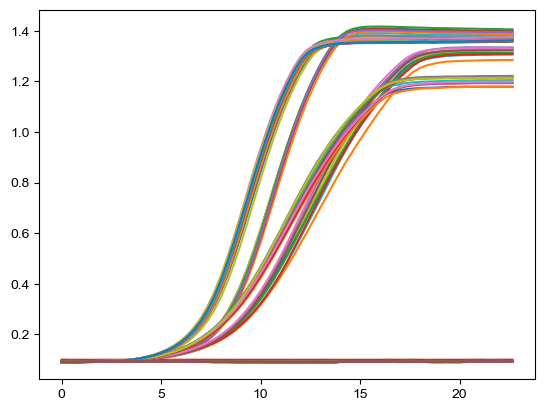

In [43]:
for well in MRPL33_data.columns:
    plt.plot(MRPL33_data[well])

In [44]:
growth_rate_dict_MRPL33 = get_growth_rate_dict(MRPL33_data)
get_AUC_dict_MRPL33 = get_AUC_dict(MRPL33_data)

MRPL33_plate_ref['growth_rate'] = pd.Series(growth_rate_dict_MRPL33)
MRPL33_plate_ref['AUC'] = pd.Series(get_AUC_dict_MRPL33)

In [45]:
MRPL33_blanks = MRPL33_plate_ref['strain']=='Blank'
MRPL33_plate_ref[~MRPL33_blanks]

,strain,sgRNA_number,biological_replicate,technical_replicate,growth_rate,AUC
well,,,,,,
B2,FRS 584,WT_CTRL,1.0,1.0,0.2523,12.122483
B3,FRS 584,WT_CTRL,1.0,2.0,0.2547,12.288917
B4,FRS 584,WT_CTRL,1.0,3.0,0.2559,12.156367
B5,FRS 584,WT_CTRL,1.0,4.0,0.2610,12.092667
B6,FRS 584,WT_CTRL,1.0,5.0,0.2514,12.076750
B7,FRS 584,WT_CTRL,2.0,1.0,0.2523,11.899283
B8,FRS 584,WT_CTRL,2.0,2.0,0.2580,12.163350
B9,FRS 584,WT_CTRL,2.0,3.0,0.2538,12.155900
B10,FRS 584,WT_CTRL,2.0,4.0,0.2559,12.168783


In [46]:
MRPL33_blank_median = MRPL33_plate_ref[MRPL33_blanks]['AUC'].median()
MRPL33_plate_ref['adjusted_AUC'] = MRPL33_plate_ref['AUC']-MRPL33_blank_median

MRPL33_plate_ref

,strain,sgRNA_number,biological_replicate,technical_replicate,growth_rate,AUC,adjusted_AUC
well,,,,,,,
A1,Blank,NaN,NaN,NaN,0.0003,1.612650,-0.016633
A2,Blank,NaN,NaN,NaN,0.0003,1.626483,-0.002800
A3,Blank,NaN,NaN,NaN,0.0003,1.633000,0.003717
A4,Blank,NaN,NaN,NaN,0.0003,1.768500,0.139217
A5,Blank,NaN,NaN,NaN,0.0003,1.642717,0.013433
...,...,...,...,...,...,...,...
H8,Blank,NaN,NaN,NaN,0.0021,1.640483,0.011200
H9,Blank,NaN,NaN,NaN,0.0018,1.647417,0.018133
H10,Blank,NaN,NaN,NaN,0.0018,1.642867,0.013583


In [47]:
MRPL33_err_plot_dict_of_dict = {}


index=0

for strain in ['WT_CTRL', 'sgRNA_221', 'sgRNA_222', 'sgRNA_223', 'sgRNA_224']:
    for biorep in [1,2]:
        val_dict = {}
        df_slice = MRPL33_plate_ref[(MRPL33_plate_ref['sgRNA_number']==strain)&(MRPL33_plate_ref['biological_replicate']==biorep)]

        auc_vals = list(df_slice['adjusted_AUC'])

        val_dict['strain'] = strain+''+str(biorep)
        val_dict['mean'] = np.mean(auc_vals)
        val_dict['err_95'] = np.mean(auc_vals) - stats.t.interval(0.95, len(auc_vals)-1, loc=np.mean(auc_vals), scale=stats.sem(auc_vals))[0]

        MRPL33_err_plot_dict_of_dict[index] = val_dict
        index+=1

        print(auc_vals)

[10.493200000375516, 10.659633393088983, 10.52708344161511, 10.463383308301372, 10.44746669133505]
[10.269999903937185, 10.534066612521812, 10.526616764565315, 10.539500005543236, 10.758716729780042]
[9.393233360101783, 9.422416624923551, 9.313566628843548, 9.383466766526304, 9.399983311692877]
[9.377966626236839, 9.21126654868325, 9.511250025282306, 9.380049956341587, 9.393483274926748]
[6.54048332820336, 6.426200055827698, 6.146400040636459, 6.346716678390901, 5.87138337145249]
[6.321383302410445, 6.158349977185329, 6.70473335683346, 6.547400017579397, 6.804716696341833]
[7.1136499543984755, 6.949433334171774, 6.7455000343422125, 7.229866676032545, 6.830866711835068]
[7.016983353843296, 7.0454833321273345, 6.941400005171699, 7.297483318795765, 7.244716738661133]
[10.634933400899177, 10.668016723046705, 10.635166774193449, 10.604416615019248, 10.585099944223964]
[10.90708330770334, 10.630333296954635, 10.81606667861343, 10.714483403911197, 10.718516727288568]


1
[10.518153366943206, 10.525780003269517] [9.374803286294147, 9.382533338417613]
TtestResult(statistic=210.57032035546175, pvalue=2.2590756883966654e-05, df=1.999637297581853)
[9.374803286294147, 9.382533338417613] 2.2590756883966654e-05
3
[10.518153366943206, 10.525780003269517] [6.507316670070094, 6.266236694902181]
TtestResult(statistic=34.28839180182592, pvalue=0.018437632354729932, df=1.0020015818761725)
[6.507316670070094, 6.266236694902181] 0.018437632354729932
5
[10.518153366943206, 10.525780003269517] [7.109213349719845, 6.9738633421560134]
TtestResult(statistic=51.347115093639616, pvalue=0.012105568327780173, df=1.0063500204545996)
[7.109213349719845, 6.9738633421560134] 0.012105568327780173
7
[10.518153366943206, 10.525780003269517] [10.757296682894234, 10.625526691476509]
TtestResult(statistic=-2.567532996635282, pvalue=0.2351037007804681, df=1.0066997432860263)
9


(2.0, 12.0)

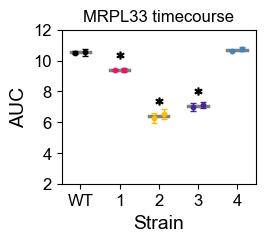

In [48]:
plt.figure(figsize=(2.5,2))


plot_index=1

color_list = ['k', 'k', '#E31964', '#E31964', '#F7BC04', '#F7BC04', '#492690', '#492690', '#4682B4', '#4682B4']

for x in range(0,10):
    plt.scatter(plot_index, MRPL33_err_plot_dict_of_dict[x]['mean'], color=color_list[x], s=10, zorder=9)
    plt.errorbar(plot_index, MRPL33_err_plot_dict_of_dict[x]['mean'], MRPL33_err_plot_dict_of_dict[x]['err_95'], color=color_list[x], elinewidth=1, capsize=2, zorder=9)
    plot_index+=1
    if x%2:
        mean = np.mean([MRPL33_err_plot_dict_of_dict[x-1]['mean'], MRPL33_err_plot_dict_of_dict[x]['mean']])
        plt.plot([plot_index-2.5, plot_index-0.5], [mean, mean], color='grey', lw=2.5)

        if x >1:
            wt_vals = [MRPL33_err_plot_dict_of_dict[0]['mean'], MRPL33_err_plot_dict_of_dict[1]['mean']]
            test_val = [MRPL33_err_plot_dict_of_dict[x]['mean'], MRPL33_err_plot_dict_of_dict[x-1]['mean']]
            print(wt_vals, test_val)
            print(scipy.stats.ttest_ind(wt_vals, test_val, equal_var=False))

            stat, pval = scipy.stats.ttest_ind(wt_vals, test_val, equal_var=False)
            if pval < 0.05:
                print(test_val, pval)
                plt.plot([plot_index-1.5], [mean+1], marker='$*$', color='k', ms=5)
        
        print(x)
        plot_index+=2


plt.title('MRPL33 timecourse')
plt.ylabel('AUC', fontsize=14)
plt.xlabel('Strain', fontsize=14)
plt.xticks([1.5,5.5,9.5,13.5,17.5],['WT', '1','2','3','4'], fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(2,12)

In [49]:
scipy.stats.ttest_ind([MRPL33_err_plot_dict_of_dict[0]['mean'], MRPL33_err_plot_dict_of_dict[1]['mean']], [MRPL33_err_plot_dict_of_dict[2]['mean'], MRPL33_err_plot_dict_of_dict[3]['mean']], equal_var=False)

TtestResult(statistic=210.57032035546175, pvalue=2.2590756883966654e-05, df=1.999637297581853)

In [50]:
2%2

0

## MMM1

In [51]:
MMM1_plate_ref = pd.read_excel('./Growth_curve_data/plate_map_MMM1.xlsx', index_col=0)
MMM1_plate_ref


,strain,sgRNA_number,medium,biological_replicate,technical_replicate
well,,,,,
A1,Blank,NaN,YPD,NaN,NaN
A2,Blank,NaN,YPD,NaN,NaN
A3,Blank,NaN,YPD,NaN,NaN
A4,Blank,NaN,YPD,NaN,NaN
A5,Blank,NaN,YPD,NaN,NaN
...,...,...,...,...,...
H8,Blank,NaN,YPD,NaN,NaN
H9,Blank,NaN,YPD,NaN,NaN
H10,Blank,NaN,YPD,NaN,NaN


In [52]:
MMM1_data = pd.read_excel('./Growth_curve_data/raw_data_MMM1.xlsx', index_col=0).T
MMM1_data

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,H3,H4,H5,H6,H7,H8,H9,H10,H11,H12
0.000000,0.1275,0.1258,0.1143,0.1197,0.1295,0.1325,0.1398,0.1367,0.1267,0.1256,...,0.1390,0.1294,0.1340,0.1269,0.1231,0.1241,0.1253,0.1279,0.1290,0.1147
0.333333,0.0972,0.0992,0.0974,0.0978,0.0987,0.0980,0.1027,0.0998,0.0984,0.0977,...,0.0998,0.0997,0.1030,0.0997,0.0986,0.1006,0.0984,0.0988,0.1028,0.1010
0.666667,0.0974,0.0992,0.0975,0.0979,0.0989,0.0983,0.1026,0.1000,0.0984,0.0980,...,0.0997,0.0995,0.1032,0.0997,0.0986,0.1009,0.0983,0.0988,0.1025,0.1010
1.000000,0.0974,0.0992,0.0976,0.0979,0.0989,0.0984,0.1025,0.0999,0.0983,0.0981,...,0.0997,0.0994,0.1033,0.0996,0.0985,0.1009,0.0983,0.0987,0.1021,0.1011
1.333333,0.0974,0.0992,0.0976,0.0979,0.0990,0.0985,0.1025,0.0999,0.0983,0.0982,...,0.0996,0.0993,0.1033,0.0995,0.0985,0.1008,0.0982,0.0986,0.1019,0.1011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22.666667,0.0970,0.0992,0.0974,0.0977,0.0986,0.0980,0.1026,0.0994,0.0983,0.0976,...,0.0977,0.0982,0.1018,0.0984,0.0972,0.0992,0.0991,0.0973,0.1014,0.0996
23.000000,0.0970,0.0992,0.0974,0.0977,0.0986,0.0980,0.1027,0.0994,0.0984,0.0977,...,0.0980,0.0986,0.1021,0.0988,0.0977,0.0996,0.0994,0.0977,0.1018,0.1000
23.333333,0.0970,0.0992,0.0974,0.0978,0.0986,0.0981,0.1027,0.0994,0.0983,0.0977,...,0.0980,0.0985,0.1020,0.0987,0.0975,0.0995,0.0994,0.0976,0.1017,0.0999
23.666667,0.0970,0.0991,0.0974,0.0977,0.0985,0.0980,0.1027,0.0995,0.0983,0.0976,...,0.0983,0.0988,0.1023,0.0990,0.0979,0.0999,0.0997,0.0979,0.1020,0.1002


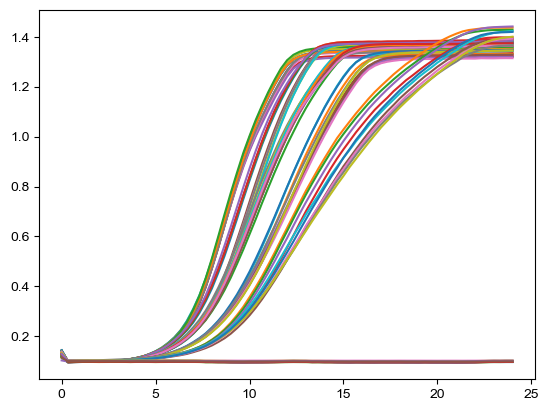

In [53]:
for well in MMM1_data.columns:
    plt.plot(MMM1_data[well])

In [54]:
growth_rate_dict_MMM1 = get_growth_rate_dict(MMM1_data)
get_AUC_dict_MMM1 = get_AUC_dict(MMM1_data)

MMM1_plate_ref['growth_rate'] = pd.Series(growth_rate_dict_MMM1)
MMM1_plate_ref['AUC'] = pd.Series(get_AUC_dict_MMM1)



In [55]:
MMM1_blanks = MMM1_plate_ref['strain']=='Blank'
MMM1_plate_ref[~MMM1_blanks]

,strain,sgRNA_number,medium,biological_replicate,technical_replicate,growth_rate,AUC
well,,,,,,,
B2,FRS 584,WT_CTRL,YPD,1.0,1.0,0.2487,12.387783
B3,FRS 584,WT_CTRL,YPD,1.0,2.0,0.2394,12.353233
B4,FRS 584,WT_CTRL,YPD,1.0,3.0,0.2499,12.534783
B5,FRS 584,WT_CTRL,YPD,1.0,4.0,0.2490,12.500583
B6,FRS 584,WT_CTRL,YPD,1.0,5.0,0.2526,12.554000
B7,FRS 584,WT_CTRL,YPD,2.0,1.0,0.2556,12.806250
B8,FRS 584,WT_CTRL,YPD,2.0,2.0,0.2487,12.723783
B9,FRS 584,WT_CTRL,YPD,2.0,3.0,0.2469,12.703050
B10,FRS 584,WT_CTRL,YPD,2.0,4.0,0.2529,12.675783


In [56]:
MMM1_blank_median = MMM1_plate_ref[MMM1_blanks]['AUC'].median()
MMM1_plate_ref['adjusted_AUC'] = MMM1_plate_ref['AUC']-MMM1_blank_median

MMM1_plate_ref

,strain,sgRNA_number,medium,biological_replicate,technical_replicate,growth_rate,AUC,adjusted_AUC
well,,,,,,,,
A1,Blank,NaN,YPD,NaN,NaN,0.0003,1.723483,-0.018808
A2,Blank,NaN,YPD,NaN,NaN,0.0003,1.759167,0.016875
A3,Blank,NaN,YPD,NaN,NaN,0.0003,1.726283,-0.016008
A4,Blank,NaN,YPD,NaN,NaN,0.0003,1.733533,-0.008758
A5,Blank,NaN,YPD,NaN,NaN,0.0003,1.751750,0.009458
...,...,...,...,...,...,...,...,...
H8,Blank,NaN,YPD,NaN,NaN,0.0009,1.763283,0.020992
H9,Blank,NaN,YPD,NaN,NaN,0.0009,1.745017,0.002725
H10,Blank,NaN,YPD,NaN,NaN,0.0009,1.726300,-0.015992


In [57]:
MMM1_err_plot_dict_of_dict = {}


index=0

for strain in ['WT_CTRL', 'sgRNA_265', 'sgRNA_266', 'sgRNA_267', 'sgRNA_268']:
    for biorep in [1,2]:
        val_dict = {}
        df_slice = MMM1_plate_ref[(MMM1_plate_ref['sgRNA_number']==strain)&(MMM1_plate_ref['biological_replicate']==biorep)]

        auc_vals = list(df_slice['adjusted_AUC'])

        val_dict['strain'] = strain+''+str(biorep)
        val_dict['mean'] = np.mean(auc_vals)
        val_dict['err_95'] = np.mean(auc_vals) - stats.t.interval(0.95, len(auc_vals)-1, loc=np.mean(auc_vals), scale=stats.sem(auc_vals))[0]

        MMM1_err_plot_dict_of_dict[index] = val_dict
        index+=1

        print(auc_vals)

[10.645491718625035, 10.61094168759883, 10.792491614197699, 10.758291678503161, 10.811708275849627]
[11.063958368574585, 10.981491716578608, 10.960758417223898, 10.933491721128428, 11.145924994722016]
[9.881724914535885, 9.832474916552508, 9.815825089191401, 9.662791691099606, 9.648575039580466]
[10.33474170851211, 10.453308363134665, 10.414141751204934, 10.467591543371485, 10.561041587963706]
[9.39274164475501, 9.312291693563266, 9.357474929963553, 9.184691771244013, 9.253208363428715]
[8.908625033373639, 9.158475028350955, 9.08442498929799, 9.082508255417151, 9.150941726441186]
[7.7574083426346405, 7.798008307193719, 7.503058278933169, 7.179074977214141, 7.1838916682948675]
[7.227758337433142, 7.202708318208657, 7.075691664591433, 7.456408326203624, 7.253058345988395]
[6.280458318069577, 6.160908358171582, 5.642391638830305, 5.9340916468451415, 5.164774976049861]
[5.186891676858069, 5.164408342912794, 5.062658341601491, 5.539208324626089, 5.465341689065099]


1
[10.72378499495487, 11.017125043645507] [10.44616499083738, 9.768278330191972]
TtestResult(statistic=2.0666105052851185, pvalue=0.23106752341428916, df=1.3618190952271962)
3
[10.72378499495487, 11.017125043645507] [9.076995006576183, 9.30008168059091]
TtestResult(statistic=9.127648916260165, pvalue=0.014588777196227042, df=1.8667876372459231)
[9.076995006576183, 9.30008168059091] 0.014588777196227042
5
[10.72378499495487, 11.017125043645507] [7.243124998485049, 7.4842883148541075]
TtestResult(statistic=18.468844594009404, pvalue=0.0034402019893200776, df=1.9278960961418816)
[7.243124998485049, 7.4842883148541075] 0.0034402019893200776
7
[10.72378499495487, 11.017125043645507] [5.283701675012709, 5.836524987593293]
TtestResult(statistic=16.970582279347926, pvalue=0.010217976451957045, df=1.5217562034401264)
[5.283701675012709, 5.836524987593293] 0.010217976451957045
9


(2.0, 12.0)

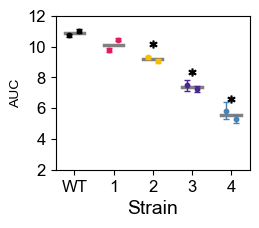

In [58]:
plt.figure(figsize=(2.5,2))


plot_index=1

color_list = ['k', 'k', '#E31964', '#E31964', '#F7BC04', '#F7BC04', '#492690', '#492690', '#4682B4', '#4682B4']

for x in range(0,10):
    plt.scatter(plot_index, MMM1_err_plot_dict_of_dict[x]['mean'], color=color_list[x], s=10, zorder=9)
    plt.errorbar(plot_index, MMM1_err_plot_dict_of_dict[x]['mean'], MMM1_err_plot_dict_of_dict[x]['err_95'], color=color_list[x], elinewidth=1, capsize=2, zorder=9)
    plot_index+=1
    if x%2:
        mean = np.mean([MMM1_err_plot_dict_of_dict[x-1]['mean'], MMM1_err_plot_dict_of_dict[x]['mean']])
        plt.plot([plot_index-2.5, plot_index-0.5], [mean, mean], color='grey', lw=2.5)

        if x >1:
            wt_vals = [MMM1_err_plot_dict_of_dict[0]['mean'], MMM1_err_plot_dict_of_dict[1]['mean']]
            test_val = [MMM1_err_plot_dict_of_dict[x]['mean'], MMM1_err_plot_dict_of_dict[x-1]['mean']]
            print(wt_vals, test_val)
            print(scipy.stats.ttest_ind(wt_vals, test_val, equal_var=False))

            stat, pval = scipy.stats.ttest_ind(wt_vals, test_val, equal_var=False)
            if pval < 0.05:
                print(test_val, pval)
                plt.plot([plot_index-1.5], [mean+1], marker='$*$', color='k', ms=5)
        
        print(x)
        plot_index+=2



plt.ylabel('AUC')
plt.xlabel('Strain', fontsize=14)
plt.xticks([1.5,5.5,9.5,13.5,17.5],['WT', '1','2','3','4'], fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(2,12)

## ASK1

In [59]:
ASK1_plate_ref = pd.read_excel('./Growth_curve_data/plate_map_ASK1.xlsx', index_col=0)
ASK1_plate_ref


,strain,sgRNA_number,biological_replicate,technical_replicate
well,,,,
A1,Blank,NaN,NaN,NaN
A2,Blank,NaN,NaN,NaN
A3,Blank,NaN,NaN,NaN
A4,Blank,NaN,NaN,NaN
A5,Blank,NaN,NaN,NaN
...,...,...,...,...
H8,Blank,NaN,NaN,NaN
H9,Blank,NaN,NaN,NaN
H10,Blank,NaN,NaN,NaN


In [60]:
ASK1_data = pd.read_excel('./Growth_curve_data/raw_data_ASK1.xlsx', index_col=0).T
ASK1_data

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,H3,H4,H5,H6,H7,H8,H9,H10,H11,H12
0.000000,0.0913,0.0915,0.0921,0.0917,0.0929,0.0963,0.0955,0.0928,0.0927,0.0920,...,0.1123,0.1092,0.1112,0.1068,0.1087,0.1068,0.1112,0.1189,0.1039,0.0995
0.333333,0.0913,0.0916,0.0921,0.0922,0.0931,0.0964,0.0957,0.0931,0.0931,0.0922,...,0.0930,0.0934,0.0954,0.0942,0.0973,0.0948,0.0968,0.0948,0.0931,0.0941
0.666667,0.0913,0.0915,0.0920,0.0923,0.0933,0.0962,0.0957,0.0930,0.0931,0.0922,...,0.0930,0.0934,0.0954,0.0941,0.0975,0.0949,0.0967,0.0948,0.0931,0.0939
1.000000,0.0913,0.0915,0.0921,0.0923,0.0934,0.0963,0.0958,0.0932,0.0930,0.0923,...,0.0931,0.0933,0.0953,0.0940,0.0974,0.0948,0.0965,0.0946,0.0930,0.0938
1.333333,0.0913,0.0916,0.0921,0.0924,0.0935,0.0962,0.0957,0.0932,0.0931,0.0922,...,0.0929,0.0930,0.0951,0.0939,0.0974,0.0947,0.0963,0.0944,0.0930,0.0936
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21.333333,0.0915,0.0924,0.0927,0.0933,0.0935,0.0970,0.0966,0.0933,0.0931,0.0921,...,0.0904,0.0908,0.0925,0.0916,0.0951,0.0926,0.0942,0.0923,0.0907,0.0915
21.666667,0.0914,0.0924,0.0926,0.0933,0.0934,0.0970,0.0966,0.0933,0.0930,0.0920,...,0.0904,0.0907,0.0924,0.0915,0.0951,0.0926,0.0941,0.0921,0.0906,0.0914
22.000000,0.0914,0.0925,0.0927,0.0933,0.0934,0.0970,0.0966,0.0933,0.0930,0.0920,...,0.0904,0.0908,0.0925,0.0916,0.0951,0.0926,0.0941,0.0923,0.0907,0.0916
22.333333,0.0914,0.0924,0.0926,0.0933,0.0934,0.0970,0.0966,0.0933,0.0930,0.0920,...,0.0906,0.0909,0.0927,0.0917,0.0952,0.0927,0.0943,0.0924,0.0908,0.0918


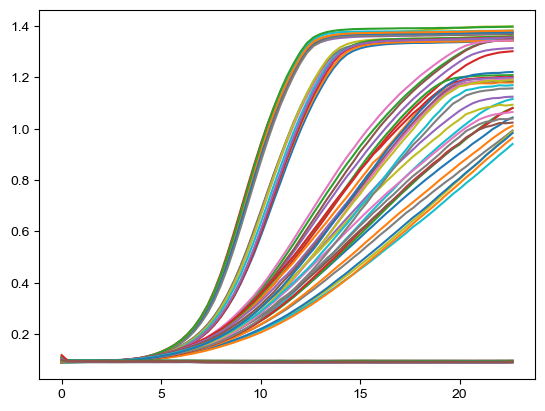

In [61]:
for well in ASK1_data.columns:
    plt.plot(ASK1_data[well])

In [62]:
growth_rate_dict_ASK1 = get_growth_rate_dict(ASK1_data)
get_AUC_dict_ASK1 = get_AUC_dict(ASK1_data)

ASK1_plate_ref['growth_rate'] = pd.Series(growth_rate_dict_ASK1)
ASK1_plate_ref['AUC'] = pd.Series(get_AUC_dict_ASK1)



In [63]:
ASK1_blanks = ASK1_plate_ref['strain']=='Blank'
ASK1_plate_ref[~ASK1_blanks]

,strain,sgRNA_number,biological_replicate,technical_replicate,growth_rate,AUC
well,,,,,,
B2,FRS 584,WT_CTRL,1.0,1.0,0.2553,12.558550
B3,FRS 584,WT_CTRL,1.0,2.0,0.2466,12.300417
B4,FRS 584,WT_CTRL,1.0,3.0,0.2502,12.281417
B5,FRS 584,WT_CTRL,1.0,4.0,0.2505,12.389867
B6,FRS 584,WT_CTRL,1.0,5.0,0.2499,12.200683
B7,FRS 584,WT_CTRL,2.0,1.0,0.2577,12.451267
B8,FRS 584,WT_CTRL,2.0,2.0,0.2553,12.532717
B9,FRS 584,WT_CTRL,2.0,3.0,0.2544,12.384550
B10,FRS 584,WT_CTRL,2.0,4.0,0.2535,12.480083


In [64]:
ASK1_blank_median = ASK1_plate_ref[ASK1_blanks]['AUC'].median()
ASK1_plate_ref['adjusted_AUC'] = ASK1_plate_ref['AUC']-ASK1_blank_median

ASK1_plate_ref

,strain,sgRNA_number,biological_replicate,technical_replicate,growth_rate,AUC,adjusted_AUC
well,,,,,,,
A1,Blank,NaN,NaN,NaN,0.0003,1.616267,-0.024567
A2,Blank,NaN,NaN,NaN,0.0003,1.626000,-0.014833
A3,Blank,NaN,NaN,NaN,0.0003,1.632983,-0.007850
A4,Blank,NaN,NaN,NaN,0.0003,1.641117,0.000283
A5,Blank,NaN,NaN,NaN,0.0003,1.651450,0.010617
...,...,...,...,...,...,...,...
H8,Blank,NaN,NaN,NaN,0.0006,1.651783,0.010950
H9,Blank,NaN,NaN,NaN,0.0003,1.681050,0.040217
H10,Blank,NaN,NaN,NaN,0.0006,1.648650,0.007817


In [65]:
ASK1_plate_ref['sgRNA_number'].unique()

array([nan, 'WT_CTRL', 'sgRNA_273', 'sgRNA_274', 'sgRNA_275', 'sgRNA_276'],
      dtype=object)

In [66]:
ASK1_err_plot_dict_of_dict = {}


index=0

for strain in ['WT_CTRL', 'sgRNA_273', 'sgRNA_274', 'sgRNA_275', 'sgRNA_276']:
    for biorep in [1,2]:
        val_dict = {}
        df_slice = ASK1_plate_ref[(ASK1_plate_ref['sgRNA_number']==strain)&(ASK1_plate_ref['biological_replicate']==biorep)]

        auc_vals = list(df_slice['adjusted_AUC'])

        val_dict['strain'] = strain+''+str(biorep)
        val_dict['mean'] = np.mean(auc_vals)
        val_dict['err_95'] = np.mean(auc_vals) - stats.t.interval(0.95, len(auc_vals)-1, loc=np.mean(auc_vals), scale=stats.sem(auc_vals))[0]

        ASK1_err_plot_dict_of_dict[index] = val_dict
        index+=1

        print(auc_vals)

[10.917716573302952, 10.659583411489928, 10.640583425139393, 10.749033293997254, 10.559850026542946]
[10.810433282827345, 10.891883332903193, 10.743716604386774, 10.839250146721806, 11.007816602165505]
[9.447783325488373, 9.361599997306868, 9.460016697024312, 9.46998334365587, 9.238816646859052]
[8.876849989717208, 9.004283343131348, 9.062933320179585, 9.036950136845313, 9.107233367239438]
[3.121683337415258, 2.7304333268354335, 2.632400029028456, 2.813916672642033, 2.610166691864531]
[5.967750038330756, 5.316716649259131, 5.62040003699561, 5.800099980706971, 6.162700005496545]
[3.8182833399623646, 3.503099995975693, 3.2143166468789173, 3.5530999892701707, 3.60693332614998]
[4.472499989594022, 3.7350999917835, 4.051216671243312, 3.838416682556272, 4.399450045699876]
[5.148500012233855, 5.453866616512341, 5.420333325242003, 4.98725000830988, 4.878683345392348]
[4.610650027170777, 4.1054999846965075, 4.605733309562009, 4.34446665706734, 4.8306834145138655]


1
[10.705353346094494, 10.858619993800925] [9.017650031422578, 9.395640002066894]
TtestResult(statistic=7.724511972418602, pvalue=0.04654207159804088, df=1.320170276852953)
[9.017650031422578, 9.395640002066894] 0.04654207159804088
3
[10.705353346094494, 10.858619993800925] [5.773533342157802, 2.7817200115571423]
TtestResult(statistic=4.342411166286442, pvalue=0.14310515691617592, df=1.0052487191574515)
5
[10.705353346094494, 10.858619993800925] [4.099336676175396, 3.5391466596474253]
TtestResult(statistic=23.977287418287084, pvalue=0.01713614208135916, df=1.1488770873995542)
[4.099336676175396, 3.5391466596474253] 0.01713614208135916
7
[10.705353346094494, 10.858619993800925] [4.499406678602099, 5.1777266615380855]
TtestResult(statistic=17.093042811989605, pvalue=0.02850465372816185, df=1.1018416878813662)
[4.499406678602099, 5.1777266615380855] 0.02850465372816185
9


(2.0, 12.0)

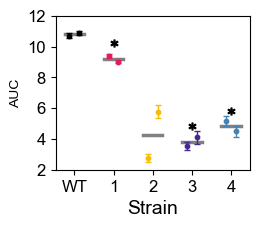

In [67]:
plt.figure(figsize=(2.5,2))


plot_index=1

color_list = ['k', 'k', '#E31964', '#E31964', '#F7BC04', '#F7BC04', '#492690', '#492690', '#4682B4', '#4682B4']

for x in range(0,10):
    plt.scatter(plot_index, ASK1_err_plot_dict_of_dict[x]['mean'], color=color_list[x], s=10, zorder=9)
    plt.errorbar(plot_index, ASK1_err_plot_dict_of_dict[x]['mean'], ASK1_err_plot_dict_of_dict[x]['err_95'], color=color_list[x], elinewidth=1, capsize=2, zorder=9)
    plot_index+=1
    if x%2:
        mean = np.mean([ASK1_err_plot_dict_of_dict[x-1]['mean'], ASK1_err_plot_dict_of_dict[x]['mean']])
        plt.plot([plot_index-2.5, plot_index-0.5], [mean, mean], color='grey', lw=2.5)

        if x >1:
            wt_vals = [ASK1_err_plot_dict_of_dict[0]['mean'], ASK1_err_plot_dict_of_dict[1]['mean']]
            test_val = [ASK1_err_plot_dict_of_dict[x]['mean'], ASK1_err_plot_dict_of_dict[x-1]['mean']]
            print(wt_vals, test_val)
            print(scipy.stats.ttest_ind(wt_vals, test_val, equal_var=False))

            stat, pval = scipy.stats.ttest_ind(wt_vals, test_val, equal_var=False)
            if pval < 0.05:
                print(test_val, pval)
                plt.plot([plot_index-1.5], [mean+1], marker='$*$', color='k', ms=5)
        
        print(x)
        plot_index+=2



plt.ylabel('AUC')
plt.xlabel('Strain', fontsize=14)
plt.xticks([1.5,5.5,9.5,13.5,17.5],['WT', '1','2','3','4'], fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(2,12)

1
[10.518153366943206, 10.525780003269517] [9.374803286294147, 9.382533338417613]
2.2590756883966654e-05
[9.374803286294147, 9.382533338417613] 2.2590756883966654e-05
3
[10.518153366943206, 10.525780003269517] [6.507316670070094, 6.266236694902181]
0.018437632354729932
[6.507316670070094, 6.266236694902181] 0.018437632354729932
5
[10.518153366943206, 10.525780003269517] [7.109213349719845, 6.9738633421560134]
0.012105568327780173
[7.109213349719845, 6.9738633421560134] 0.012105568327780173
7
[10.518153366943206, 10.525780003269517] [10.757296682894234, 10.625526691476509]
0.2351037007804681
9
1
[10.72378499495487, 11.017125043645507] [10.44616499083738, 9.768278330191972]
0.23106752341428916
3
[10.72378499495487, 11.017125043645507] [9.076995006576183, 9.30008168059091]
0.014588777196227042
[9.076995006576183, 9.30008168059091] 0.014588777196227042
5
[10.72378499495487, 11.017125043645507] [7.243124998485049, 7.4842883148541075]
0.0034402019893200776
[7.243124998485049, 7.4842883148541

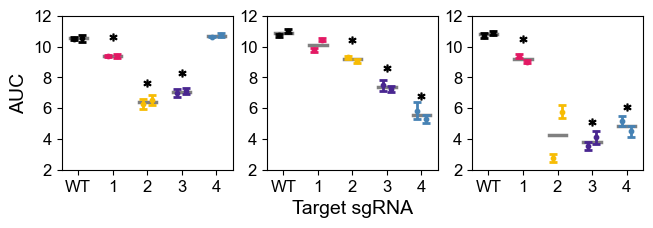

In [68]:
plt.figure(figsize=(7.5,2))

######### MRPL33
ax1 = plt.subplot(131)

plot_index=1

color_list = ['k', 'k', '#E31964', '#E31964', '#F7BC04', '#F7BC04', '#492690', '#492690', '#4682B4', '#4682B4']

for x in range(0,10):
    plt.scatter(plot_index, MRPL33_err_plot_dict_of_dict[x]['mean'], color=color_list[x], s=10, zorder=9)
    plt.errorbar(plot_index, MRPL33_err_plot_dict_of_dict[x]['mean'], MRPL33_err_plot_dict_of_dict[x]['err_95'], color=color_list[x], elinewidth=2, capsize=3, capthick=2, zorder=9)
    plot_index+=1
    if x%2:
        mean = np.mean([MRPL33_err_plot_dict_of_dict[x-1]['mean'], MRPL33_err_plot_dict_of_dict[x]['mean']])
        plt.plot([plot_index-2.5, plot_index-0.5], [mean, mean], color='grey', lw=2.5)

        if x >1:
            wt_vals = [MRPL33_err_plot_dict_of_dict[0]['mean'], MRPL33_err_plot_dict_of_dict[1]['mean']]
            test_val = [MRPL33_err_plot_dict_of_dict[x]['mean'], MRPL33_err_plot_dict_of_dict[x-1]['mean']]
            print(wt_vals, test_val)
            print(scipy.stats.ttest_ind(wt_vals, test_val, equal_var=False)[1])

            stat, pval = scipy.stats.ttest_ind(wt_vals, test_val, equal_var=False)
            if pval < 0.05:
                print(test_val, pval)
                plt.plot([plot_index-1.5], [mean+1.25], marker='$*$', color='k', ms=5)
        
        print(x)
        plot_index+=2

    


plt.ylabel('AUC', fontsize=14)
plt.xlabel('', fontsize=14)
plt.xticks([1.5,5.5,9.5,13.5,17.5],['WT', '1','2','3','4'], fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(2,12)


######### MMM1
ax2 = plt.subplot(132)

plot_index=1

color_list = ['k', 'k', '#E31964', '#E31964', '#F7BC04', '#F7BC04', '#492690', '#492690', '#4682B4', '#4682B4']

for x in range(0,10):
    plt.scatter(plot_index, MMM1_err_plot_dict_of_dict[x]['mean'], color=color_list[x], s=10, zorder=9)
    plt.errorbar(plot_index, MMM1_err_plot_dict_of_dict[x]['mean'], MMM1_err_plot_dict_of_dict[x]['err_95'], color=color_list[x], elinewidth=2, capsize=3, capthick=2, zorder=9)
    plot_index+=1
    if x%2:
        mean = np.mean([MMM1_err_plot_dict_of_dict[x-1]['mean'], MMM1_err_plot_dict_of_dict[x]['mean']])
        plt.plot([plot_index-2.5, plot_index-0.5], [mean, mean], color='grey', lw=2.5)

        if x >1:
            wt_vals = [MMM1_err_plot_dict_of_dict[0]['mean'], MMM1_err_plot_dict_of_dict[1]['mean']]
            test_val = [MMM1_err_plot_dict_of_dict[x]['mean'], MMM1_err_plot_dict_of_dict[x-1]['mean']]
            print(wt_vals, test_val)
            print(scipy.stats.ttest_ind(wt_vals, test_val, equal_var=False)[1])

            stat, pval = scipy.stats.ttest_ind(wt_vals, test_val, equal_var=False)
            if pval < 0.05:
                print(test_val, pval)
                plt.plot([plot_index-1.5], [mean+1.25], marker='$*$', color='k', ms=5)
        
        print(x)
        plot_index+=2



plt.ylabel('')
plt.xlabel('Target sgRNA', fontsize=14)
plt.xticks([1.5,5.5,9.5,13.5,17.5],['WT', '1','2','3','4'], fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(2,12)


######### ASK1
ax3 = plt.subplot(133)


plot_index=1

color_list = ['k', 'k', '#E31964', '#E31964', '#F7BC04', '#F7BC04', '#492690', '#492690', '#4682B4', '#4682B4']

for x in range(0,10):
    plt.scatter(plot_index, ASK1_err_plot_dict_of_dict[x]['mean'], color=color_list[x], s=10, zorder=9)
    plt.errorbar(plot_index, ASK1_err_plot_dict_of_dict[x]['mean'], ASK1_err_plot_dict_of_dict[x]['err_95'], color=color_list[x], elinewidth=2, capsize=3, capthick=2, zorder=9)
    plot_index+=1
    if x%2:
        mean = np.mean([ASK1_err_plot_dict_of_dict[x-1]['mean'], ASK1_err_plot_dict_of_dict[x]['mean']])
        plt.plot([plot_index-2.5, plot_index-0.5], [mean, mean], color='grey', lw=2.5)

        if x >1:
            wt_vals = [ASK1_err_plot_dict_of_dict[0]['mean'], ASK1_err_plot_dict_of_dict[1]['mean']]
            test_val = [ASK1_err_plot_dict_of_dict[x]['mean'], ASK1_err_plot_dict_of_dict[x-1]['mean']]
            print(wt_vals, test_val)
            print(scipy.stats.ttest_ind(wt_vals, test_val, equal_var=False)[1])

            stat, pval = scipy.stats.ttest_ind(wt_vals, test_val, equal_var=False)
            if pval < 0.05:
                print(test_val, pval)
                plt.plot([plot_index-1.5], [mean+1.25], marker='$*$', color='k', ms=5)
        
        print(x)
        plot_index+=2


  



plt.ylabel('')
plt.xlabel('', fontsize=14)
plt.xticks([1.5,5.5,9.5,13.5,17.5],['WT', '1','2','3','4'], fontsize=12)
plt.yticks(fontsize=12)

plt.ylim(2,12)

plt.savefig('./figures/validatons_timecourse.svg', dpi=300)

# FBA1 glucose vs glycerol

In [69]:
FBA1_plate_ref = pd.read_excel('./Growth_curve_data/FBA1_plate_map.xlsx', index_col=0)
FBA1_plate_ref

,strain,sgRNA_number,medium,biological_replicate,technical_replicate
well,,,,,
A1,Blank,NaN,YPD,NaN,NaN
A2,Blank,NaN,YPD,NaN,NaN
A3,Blank,NaN,YPD,NaN,NaN
A4,Blank,NaN,YPD,NaN,NaN
A5,Blank,NaN,YPD,NaN,NaN
...,...,...,...,...,...
H8,Blank,NaN,YPD,NaN,NaN
H9,Blank,NaN,YPD,NaN,NaN
H10,Blank,NaN,YPD,NaN,NaN


In [70]:
FBA1_data = pd.read_excel('./Growth_curve_data/raw_data_FBA1.xlsx', index_col=0).T
FBA1_data

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,H3,H4,H5,H6,H7,H8,H9,H10,H11,H12
0.000000,0.1081,0.1083,0.1085,0.1091,0.1097,0.1111,0.1111,0.1116,0.1100,0.1088,...,0.1079,0.1086,0.1071,0.1072,0.1080,0.1084,0.1106,0.1077,0.1079,0.1080
0.333333,0.1075,0.1084,0.1082,0.1090,0.1091,0.1105,0.1105,0.1110,0.1093,0.1082,...,0.1079,0.1085,0.1071,0.1072,0.1079,0.1084,0.1106,0.1075,0.1078,0.1079
0.666667,0.1074,0.1083,0.1082,0.1092,0.1090,0.1104,0.1107,0.1108,0.1092,0.1080,...,0.1077,0.1084,0.1071,0.1071,0.1078,0.1082,0.1105,0.1074,0.1077,0.1078
1.000000,0.1074,0.1083,0.1084,0.1092,0.1090,0.1104,0.1103,0.1108,0.1092,0.1081,...,0.1088,0.1094,0.1080,0.1081,0.1088,0.1092,0.1115,0.1084,0.1086,0.1088
1.333333,0.1075,0.1083,0.1084,0.1093,0.1090,0.1104,0.1103,0.1108,0.1092,0.1081,...,0.1096,0.1103,0.1089,0.1090,0.1096,0.1101,0.1123,0.1092,0.1094,0.1096
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22.666667,0.1077,0.1086,0.1088,0.1097,0.1089,0.1105,0.1104,0.1110,0.1094,0.1084,...,0.1079,0.1097,0.1074,0.1074,0.1082,0.1087,0.1111,0.1080,0.1082,0.1085
23.000000,0.1078,0.1086,0.1089,0.1097,0.1089,0.1105,0.1104,0.1112,0.1095,0.1084,...,0.1081,0.1100,0.1076,0.1076,0.1083,0.1089,0.1112,0.1082,0.1084,0.1087
23.333333,0.1078,0.1086,0.1088,0.1097,0.1089,0.1105,0.1104,0.1111,0.1095,0.1084,...,0.1080,0.1099,0.1076,0.1076,0.1084,0.1089,0.1112,0.1082,0.1084,0.1086
23.666667,0.1077,0.1086,0.1088,0.1097,0.1088,0.1105,0.1104,0.1111,0.1094,0.1084,...,0.1080,0.1090,0.1075,0.1076,0.1083,0.1088,0.1112,0.1081,0.1083,0.1086


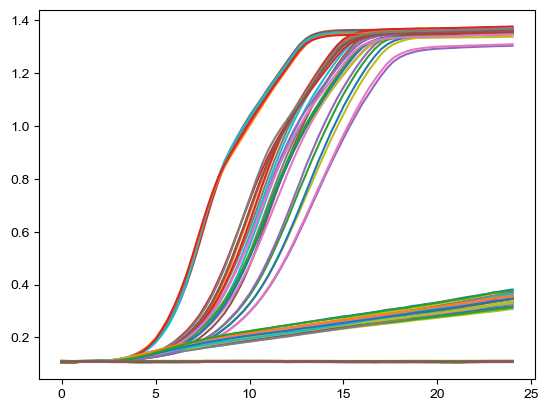

In [71]:
for well in FBA1_data.columns:
    plt.plot(FBA1_data[well])

In [72]:
growth_rate_dict_FBA1 = get_growth_rate_dict(FBA1_data)
get_AUC_dict_FBA1 = get_AUC_dict(FBA1_data)

FBA1_plate_ref['growth_rate'] = pd.Series(growth_rate_dict_FBA1)
FBA1_plate_ref['AUC'] = pd.Series(get_AUC_dict_FBA1)

In [73]:
FBA1_blanks = FBA1_plate_ref['strain']=='Blank'
FBA1_plate_ref[~FBA1_blanks]

,strain,sgRNA_number,medium,biological_replicate,technical_replicate,growth_rate,AUC
well,,,,,,,
B2,FRS 584,WT_CTRL,YPD,1.0,1.0,0.2364,13.477667
B3,FRS 1294,sgRNA_277,YPD,1.0,1.0,0.1551,7.435783
B4,FRS 1295,sgRNA_278,YPD,1.0,1.0,0.1980,9.904000
B5,FRS 1296,sgRNA_279,YPD,1.0,1.0,0.1731,9.632283
B6,FRS 1297,sgRNA_280,YPD,1.0,1.0,0.1923,10.797450
B7,FRS 584,WT_CTRL,YP+GLY,1.0,1.0,0.0135,3.110033
B8,FRS 1294,sgRNA_277,YP+GLY,1.0,1.0,0.0126,3.119633
B9,FRS 1295,sgRNA_278,YP+GLY,1.0,1.0,0.0132,3.150467
B10,FRS 1296,sgRNA_279,YP+GLY,1.0,1.0,0.0129,3.127067


In [74]:
FBA1_blank_median = FBA1_plate_ref[FBA1_blanks]['AUC'].median()
FBA1_plate_ref['adjusted_AUC'] = FBA1_plate_ref['AUC']-FBA1_blank_median

FBA1_plate_ref

,strain,sgRNA_number,medium,biological_replicate,technical_replicate,growth_rate,AUC,adjusted_AUC
well,,,,,,,,
A1,Blank,NaN,YPD,NaN,NaN,0.0003,1.900950,-0.017392
A2,Blank,NaN,YPD,NaN,NaN,0.0003,1.916583,-0.001758
A3,Blank,NaN,YPD,NaN,NaN,0.0003,1.918983,0.000642
A4,Blank,NaN,YPD,NaN,NaN,0.0006,1.933017,0.014675
A5,Blank,NaN,YPD,NaN,NaN,0.0003,1.924633,0.006292
...,...,...,...,...,...,...,...,...
H8,Blank,NaN,YPD,NaN,NaN,0.0024,1.920283,0.001942
H9,Blank,NaN,YPD,NaN,NaN,0.0024,1.960950,0.042608
H10,Blank,NaN,YPD,NaN,NaN,0.0024,1.906717,-0.011625


In [75]:
FBA1_err_plot_dict_of_dict = {}


index=0

for strain in ['WT_CTRL', 'sgRNA_277', 'sgRNA_278', 'sgRNA_279', 'sgRNA_280']:
    for biorep in [1,2]:
        for media in ['YPD', 'YP+GLY']:
            val_dict = {}
            df_slice = FBA1_plate_ref[(FBA1_plate_ref['sgRNA_number']==strain)&(FBA1_plate_ref['biological_replicate']==biorep)&(FBA1_plate_ref['medium']==media)]
    
            auc_vals = list(df_slice['adjusted_AUC'])
    
            val_dict['strain'] = strain+''+str(biorep)
            val_dict['media'] = media
            val_dict['mean'] = np.mean(auc_vals)
            val_dict['err_95'] = np.mean(auc_vals) - stats.t.interval(0.95, len(auc_vals)-1, loc=np.mean(auc_vals), scale=stats.sem(auc_vals))[0]
    
            FBA1_err_plot_dict_of_dict[index] = val_dict
            index+=1

FBA1_err_plot_dict_of_dict

{0: {'strain': 'WT_CTRL1',
  'media': 'YPD',
  'mean': 11.601713894762932,
  'err_95': 0.16117963280545844},
 1: {'strain': 'WT_CTRL1',
  'media': 'YP+GLY',
  'mean': 1.231080553390914,
  'err_95': 0.08750233697991527},
 2: {'strain': 'WT_CTRL2',
  'media': 'YPD',
  'mean': 11.542436115650673,
  'err_95': 0.08683750582638616},
 3: {'strain': 'WT_CTRL2',
  'media': 'YP+GLY',
  'mean': 1.4312972403648836,
  'err_95': 0.1566040515927396},
 4: {'strain': 'sgRNA_2771',
  'media': 'YPD',
  'mean': 5.752997250399655,
  'err_95': 0.8592456482473034},
 5: {'strain': 'sgRNA_2771',
  'media': 'YP+GLY',
  'mean': 1.235258345595665,
  'err_95': 0.10171631108861501},
 6: {'strain': 'sgRNA_2772',
  'media': 'YPD',
  'mean': 6.599213859480288,
  'err_95': 0.7548799891587148},
 7: {'strain': 'sgRNA_2772',
  'media': 'YP+GLY',
  'mean': 1.237663887648119,
  'err_95': 0.2262151848582925},
 8: {'strain': 'sgRNA_2781',
  'media': 'YPD',
  'mean': 8.182502812602456,
  'err_95': 0.5189492880509565},
 9: {'st

In [76]:
FBA1_WT_YPD_mean = (FBA1_err_plot_dict_of_dict[0]['mean']+FBA1_err_plot_dict_of_dict[2]['mean'])/2
FBA1_WT_GLY_mean = (FBA1_err_plot_dict_of_dict[1]['mean']+FBA1_err_plot_dict_of_dict[3]['mean'])/2

FBA1_WT_YPD_mean, FBA1_WT_GLY_mean

(11.572075005206802, 1.3311888968778987)

In [77]:
legend_elements =  [Line2D([0], [0], marker='o', color='w', label='YPD', markerfacecolor='k', markersize=12),
                    Line2D([0], [0], marker='D', color='w', label='GLY', markerfacecolor='k', markersize=12)]

1.0
1
0.5337077017009534
3
0.7473604445290379
5
0.6960813473255437
7
0.7763022422973384
9
1.0
11
0.9288397157772452
13
0.9714791253147781
15
1.0507503686623991
17
1.1352132908033812
19


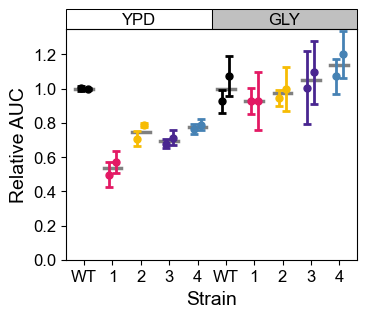

In [78]:
plt.figure(figsize=(3.75,3))
ax = plt.subplot(111)


plot_index=1

color_list = ['k', 'k', '#E31964', '#E31964','#F7BC04', '#F7BC04','#492690','#492690','#4682B4','#4682B4']*2

key_order = [0,  2,  4,  6,  8, 10, 12, 14, 16, 18,
             1,  3,  5,  7,  9, 11, 13, 15, 17, 19]


for x in range(0,20):
    if key_order[x]%2==0:
        plt.scatter(plot_index, FBA1_err_plot_dict_of_dict[key_order[x]]['mean']/FBA1_WT_YPD_mean, color=color_list[x], s=25, zorder=9)
        plt.errorbar(plot_index, FBA1_err_plot_dict_of_dict[key_order[x]]['mean']/FBA1_WT_YPD_mean, FBA1_err_plot_dict_of_dict[key_order[x]]['err_95']/FBA1_WT_YPD_mean, 
                     color=color_list[x], elinewidth=2, capsize=3, capthick=2, zorder=9)

    else:
        plt.scatter(plot_index, FBA1_err_plot_dict_of_dict[key_order[x]]['mean']/FBA1_WT_GLY_mean, color=color_list[x], s=25, zorder=9)
        plt.errorbar(plot_index, FBA1_err_plot_dict_of_dict[key_order[x]]['mean']/FBA1_WT_GLY_mean, FBA1_err_plot_dict_of_dict[key_order[x]]['err_95']/FBA1_WT_GLY_mean, 
                     color=color_list[x], elinewidth=2, capsize=3, capthick=2, zorder=9)
    plot_index+=1

    if x%2:
        if key_order[x]%2==0:
            mean = np.mean([FBA1_err_plot_dict_of_dict[key_order[x]]['mean'], FBA1_err_plot_dict_of_dict[key_order[x-1]]['mean']])/FBA1_WT_YPD_mean
            print(mean)
            plt.plot([plot_index-2.75, plot_index-0.25], [mean, mean], color='grey', lw=2.5)

        else:
            mean = np.mean([FBA1_err_plot_dict_of_dict[key_order[x]]['mean'], FBA1_err_plot_dict_of_dict[key_order[x-1]]['mean']])/FBA1_WT_GLY_mean
            print(mean)
            plt.plot([plot_index-2.75, plot_index-0.25], [mean, mean], color='grey', lw=2.5)
            
        if x >1:
            wt_vals = [FBA1_err_plot_dict_of_dict[0]['mean'], FBA1_err_plot_dict_of_dict[1]['mean']]
            test_val = [FBA1_err_plot_dict_of_dict[x]['mean'], FBA1_err_plot_dict_of_dict[x-1]['mean']]
            #print(wt_vals, test_val)
            #print(scipy.stats.ttest_ind(wt_vals, test_val, equal_var=False)[1])

            stat, pval = scipy.stats.ttest_ind(wt_vals, test_val, equal_var=False)
            if pval < 0.05:
                #print(test_val, pval)
                plt.plot([plot_index-1.5], [mean+1.25], marker='$*$', color='k', ms=5)
        
        print(x)
        plot_index+=2


ax.add_patch(plt.Rectangle((-1,1.35),41/2, 1.35/12,facecolor='w',
                              clip_on=False,linewidth = 0.75, edgecolor='k'))

plt.text(x=((41/4)-1), y=1.375, s='YPD', fontsize=12, ha='center')

ax.add_patch(plt.Rectangle(((41/2-1),1.35),41/2, 1.35/12,facecolor='silver',
                              clip_on=False, linewidth = 0.75, edgecolor='k'))

plt.text(x=((41*0.75)-1), y=1.375, s='GLY', fontsize=12, ha='center')


plt.ylabel('Relative AUC', fontsize=14)
plt.xlabel('Strain', fontsize=14)
plt.xticks([1.5, 5.5, 9.5, 13.5, 17.5, 21.5, 25.5, 29.5, 33.5, 37.5], ['WT', '1', '2', '3','4']*2, fontsize=12)
plt.yticks(fontsize=12)
plt.xlim(-1,40)
plt.ylim(0,1.35)
plt.savefig('./figures/FBA1_validations.svg', format='svg', dpi=300)

In [79]:
[x for x in range(0,20,2)]

[0, 2, 4, 6, 8, 10, 12, 14, 16, 18]

### FBA1 qPCR

In [138]:
qpcr_FBA1_glucose_df = pd.read_excel('./qPCR/FBA1_glucose.xlsx')
qpcr_FBA1_glucose_df

,Strain,sgRNA,rep,Cq_ACT1,Cq_FBA1
0,WT,CTRL,1,14.462717,11.396761
1,WT,CTRL,2,13.925197,10.723100
2,WT,CTRL,3,14.230509,11.194983
3,WT,277,1,14.543647,13.965421
4,WT,277,2,14.175371,13.623648
5,WT,277,3,14.372232,13.665056
6,WT,278,1,14.402745,13.621894
7,WT,278,2,14.253860,13.542192
8,WT,278,3,14.095557,13.716674
9,WT,279,1,14.506104,13.718247


In [139]:
baseline_ACT1_glu = qpcr_FBA1_glucose_df.loc[[0,1,2]]['Cq_ACT1'].mean()
baseline_FBA1_glu = qpcr_FBA1_glucose_df.loc[[0,1,2]]['Cq_FBA1'].mean()


baseline_ACT1_glu, baseline_FBA1_glu

(14.206141119274568, 11.104948006431366)

In [140]:
deltaATC1_ctrl_glu = baseline_FBA1_glu-baseline_ACT1_glu
deltaATC1_ctrl_glu

-3.1011931128432018

In [141]:
qpcr_FBA1_glucose_df['deltaFBA1'] =  qpcr_FBA1_glucose_df['Cq_FBA1'] - qpcr_FBA1_glucose_df['Cq_ACT1']
qpcr_FBA1_glucose_df

,Strain,sgRNA,rep,Cq_ACT1,Cq_FBA1,deltaFBA1
0,WT,CTRL,1,14.462717,11.396761,-3.065956
1,WT,CTRL,2,13.925197,10.723100,-3.202097
2,WT,CTRL,3,14.230509,11.194983,-3.035526
3,WT,277,1,14.543647,13.965421,-0.578226
4,WT,277,2,14.175371,13.623648,-0.551723
5,WT,277,3,14.372232,13.665056,-0.707176
6,WT,278,1,14.402745,13.621894,-0.780851
7,WT,278,2,14.253860,13.542192,-0.711668
8,WT,278,3,14.095557,13.716674,-0.378883
9,WT,279,1,14.506104,13.718247,-0.787857


In [142]:
qpcr_FBA1_glucose_df['deltadeltaFBA1'] = qpcr_FBA1_glucose_df['deltaFBA1']-deltaATC1_ctrl_glu

qpcr_FBA1_glucose_df

,Strain,sgRNA,rep,Cq_ACT1,Cq_FBA1,deltaFBA1,deltadeltaFBA1
0,WT,CTRL,1,14.462717,11.396761,-3.065956,0.035237
1,WT,CTRL,2,13.925197,10.723100,-3.202097,-0.100904
2,WT,CTRL,3,14.230509,11.194983,-3.035526,0.065667
3,WT,277,1,14.543647,13.965421,-0.578226,2.522967
4,WT,277,2,14.175371,13.623648,-0.551723,2.549470
5,WT,277,3,14.372232,13.665056,-0.707176,2.394017
6,WT,278,1,14.402745,13.621894,-0.780851,2.320342
7,WT,278,2,14.253860,13.542192,-0.711668,2.389525
8,WT,278,3,14.095557,13.716674,-0.378883,2.722310
9,WT,279,1,14.506104,13.718247,-0.787857,2.313336


In [143]:
qpcr_FBA1_glucose_df['FBA1_fold_repression'] = 2**qpcr_FBA1_glucose_df['deltadeltaFBA1']
qpcr_FBA1_glucose_df

,Strain,sgRNA,rep,Cq_ACT1,Cq_FBA1,deltaFBA1,deltadeltaFBA1,FBA1_fold_repression
0,WT,CTRL,1,14.462717,11.396761,-3.065956,0.035237,1.024725
1,WT,CTRL,2,13.925197,10.723100,-3.202097,-0.100904,0.932448
2,WT,CTRL,3,14.230509,11.194983,-3.035526,0.065667,1.046569
3,WT,277,1,14.543647,13.965421,-0.578226,2.522967,5.747629
4,WT,277,2,14.175371,13.623648,-0.551723,2.549470,5.854192
5,WT,277,3,14.372232,13.665056,-0.707176,2.394017,5.256188
6,WT,278,1,14.402745,13.621894,-0.780851,2.320342,4.994505
7,WT,278,2,14.253860,13.542192,-0.711668,2.389525,5.239848
8,WT,278,3,14.095557,13.716674,-0.378883,2.722310,6.599286
9,WT,279,1,14.506104,13.718247,-0.787857,2.313336,4.970310


In [144]:
mean_list_glu = list(qpcr_FBA1_glucose_df.groupby(['sgRNA'])['FBA1_fold_repression'].mean())
mean_list_glu

[5.619336289604945,
 5.611212909097098,
 5.225797767029284,
 4.816156458736796,
 1.0012474617795535]

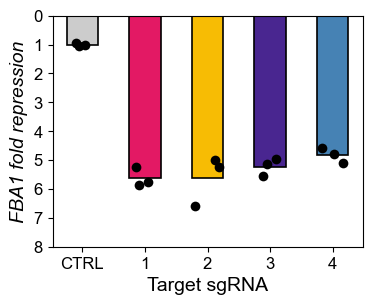

In [145]:
plt.figure(figsize=(4, 3))

sns.stripplot(data=qpcr_FBA1_glucose_df, x='sgRNA', y='FBA1_fold_repression', color='k', jitter=0.2, order=['CTRL', 277,278,279,280], size=7)

plt.bar([1,2,3,4,0], mean_list_glu, color=[ '#E31964', '#F7BC04', '#492690', '#4682B4', '#ccccccff'], edgecolor='k', linewidth=1.2,width=0.5)

plt.yticks(fontsize=12)

plt.ylim(8,0)

plt.xticks([0,1,2,3,4], ['CTRL','1','2','3','4'], fontsize=12)
plt.xlabel('Target sgRNA', fontsize=14)
plt.ylabel('FBA1 fold repression', fontsize=14, style='italic')
plt.savefig('./figures/FBA1_glucose.svg', format='svg', dpi=300)

In [146]:
qpcr_FBA1_glycerol_df = pd.read_excel('./qPCR/FBA1_glycerol.xlsx')
qpcr_FBA1_glycerol_df

,Strain,sgRNA,rep,Cq_ACT1,Cq_FBA1
0,WT,CTRL,1,13.146768,11.514669
1,WT,CTRL,2,12.498980,10.739757
2,WT,CTRL,3,13.025938,11.844685
3,WT,277,1,13.067228,14.287349
4,WT,277,2,12.787676,13.982426
5,WT,277,3,12.645614,13.816682
6,WT,278,1,12.392851,13.767650
7,WT,278,2,12.785114,13.527623
8,WT,278,3,12.813682,13.750808
9,WT,279,1,12.568195,13.178097


In [147]:
baseline_ACT1_gly = qpcr_FBA1_glycerol_df.loc[[0,1,2]]['Cq_ACT1'].mean()
baseline_FBA1_gly = qpcr_FBA1_glycerol_df.loc[[0,1,2]]['Cq_FBA1'].mean()


baseline_ACT1_gly, baseline_FBA1_gly

(12.890562184730333, 11.366370182909568)

In [148]:
deltaATC1_ctrl_gly = baseline_FBA1_gly-baseline_ACT1_gly
deltaATC1_ctrl_gly

-1.524192001820765

In [149]:
qpcr_FBA1_glycerol_df['deltaFBA1'] =  qpcr_FBA1_glycerol_df['Cq_FBA1'] - qpcr_FBA1_glycerol_df['Cq_ACT1']
qpcr_FBA1_glycerol_df

,Strain,sgRNA,rep,Cq_ACT1,Cq_FBA1,deltaFBA1
0,WT,CTRL,1,13.146768,11.514669,-1.632099
1,WT,CTRL,2,12.498980,10.739757,-1.759223
2,WT,CTRL,3,13.025938,11.844685,-1.181254
3,WT,277,1,13.067228,14.287349,1.220121
4,WT,277,2,12.787676,13.982426,1.194751
5,WT,277,3,12.645614,13.816682,1.171068
6,WT,278,1,12.392851,13.767650,1.374800
7,WT,278,2,12.785114,13.527623,0.742508
8,WT,278,3,12.813682,13.750808,0.937126
9,WT,279,1,12.568195,13.178097,0.609902


In [150]:
qpcr_FBA1_glycerol_df['deltadeltaFBA1'] = qpcr_FBA1_glycerol_df['deltaFBA1']-deltaATC1_ctrl_gly

qpcr_FBA1_glycerol_df

,Strain,sgRNA,rep,Cq_ACT1,Cq_FBA1,deltaFBA1,deltadeltaFBA1
0,WT,CTRL,1,13.146768,11.514669,-1.632099,-0.107907
1,WT,CTRL,2,12.498980,10.739757,-1.759223,-0.235031
2,WT,CTRL,3,13.025938,11.844685,-1.181254,0.342938
3,WT,277,1,13.067228,14.287349,1.220121,2.744313
4,WT,277,2,12.787676,13.982426,1.194751,2.718943
5,WT,277,3,12.645614,13.816682,1.171068,2.695260
6,WT,278,1,12.392851,13.767650,1.374800,2.898992
7,WT,278,2,12.785114,13.527623,0.742508,2.266700
8,WT,278,3,12.813682,13.750808,0.937126,2.461318
9,WT,279,1,12.568195,13.178097,0.609902,2.134094


In [151]:
qpcr_FBA1_glycerol_df['FBA1_fold_repression'] = 2**qpcr_FBA1_glycerol_df['deltadeltaFBA1']
qpcr_FBA1_glycerol_df

,Strain,sgRNA,rep,Cq_ACT1,Cq_FBA1,deltaFBA1,deltadeltaFBA1,FBA1_fold_repression
0,WT,CTRL,1,13.146768,11.514669,-1.632099,-0.107907,0.927933
1,WT,CTRL,2,12.498980,10.739757,-1.759223,-0.235031,0.849667
2,WT,CTRL,3,13.025938,11.844685,-1.181254,0.342938,1.268337
3,WT,277,1,13.067228,14.287349,1.220121,2.744313,6.700706
4,WT,277,2,12.787676,13.982426,1.194751,2.718943,6.583900
5,WT,277,3,12.645614,13.816682,1.171068,2.695260,6.476704
6,WT,278,1,12.392851,13.767650,1.374800,2.898992,7.459048
7,WT,278,2,12.785114,13.527623,0.742508,2.266700,4.812212
8,WT,278,3,12.813682,13.750808,0.937126,2.461318,5.507198
9,WT,279,1,12.568195,13.178097,0.609902,2.134094,4.389614


In [152]:
mean_list_gly = list(qpcr_FBA1_glycerol_df.groupby(['sgRNA'])['FBA1_fold_repression'].mean())
mean_list_gly

[6.58710336344641,
 5.926152689849481,
 4.299805961711989,
 5.3985015731429895,
 1.0153123237143051]

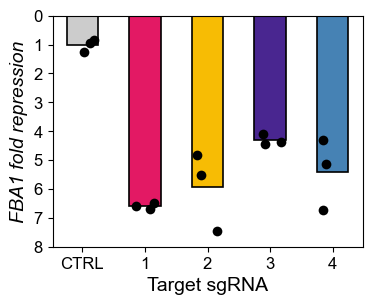

In [153]:
plt.figure(figsize=(4, 3))

sns.stripplot(data=qpcr_FBA1_glycerol_df, x='sgRNA', y='FBA1_fold_repression', color='k', jitter=0.2, order=['CTRL', 277,278,279,280], size=7)

plt.bar([1,2,3,4,0], mean_list_gly, color=[ '#E31964', '#F7BC04', '#492690', '#4682B4', '#ccccccff'], edgecolor='k', linewidth=1.2,width=0.5)

plt.yticks(fontsize=12)

plt.ylim(8,0)

plt.xticks([0,1,2,3,4], ['CTRL','1','2','3','4'], fontsize=12)
plt.xlabel('Target sgRNA', fontsize=14)
plt.ylabel('FBA1 fold repression', fontsize=14, style='italic')
plt.savefig('./figures/FBA1_glycerol.svg', format='svg', dpi=300)

# HSP90 test in the three backgrounds

## qPCR data

In [154]:
qpcr_HSP90_comp_df = pd.read_excel('./qPCR/HSP90_3_backgrounds.xlsx')
qpcr_HSP90_comp_df

,Strain,sgRNA,rep,Cq_ACT1,Cq_HSP90
0,WT,CTRL,1,13.128234,13.935995
1,WT,CTRL,2,13.219283,13.792757
2,WT,CTRL,3,12.830720,13.697784
3,FLUr,CTRL,1,12.776412,13.263531
4,FLUr,CTRL,2,12.588025,13.223753
5,FLUr,CTRL,3,12.673057,13.318525
6,CASPr,CTRL,1,12.826452,13.519404
7,CASPr,CTRL,2,13.086034,13.308526
8,CASPr,CTRL,3,12.945835,13.313719
9,WT,HSP90,1,12.793331,16.162801


In [155]:
qpcr_HSP90_comp_df.loc[[0,1,2]].columns

Index(['Strain', 'sgRNA', 'rep', 'Cq_ACT1', 'Cq_HSP90'], dtype='object')

In [156]:
baseline_ACT1_WT = qpcr_HSP90_comp_df.loc[[0,1,2]]['Cq_ACT1'].mean()
baseline_ACT1_FLUr = qpcr_HSP90_comp_df.loc[[3,4,5]]['Cq_ACT1'].mean()
baseline_ACT1_CASPr = qpcr_HSP90_comp_df.loc[[6,7,8]]['Cq_ACT1'].mean()

baseline_HSP90_WT = qpcr_HSP90_comp_df.loc[[0,1,2]]['Cq_HSP90'].mean()
baseline_HSP90_FLUr = qpcr_HSP90_comp_df.loc[[3,4,5]]['Cq_HSP90'].mean()
baseline_HSP90_CASPr = qpcr_HSP90_comp_df.loc[[6,7,8]]['Cq_HSP90'].mean()


baseline_ACT1_WT, baseline_ACT1_FLUr, baseline_ACT1_CASPr, baseline_HSP90_WT, baseline_HSP90_FLUr, baseline_HSP90_CASPr

(13.059412276748533,
 12.679164601520199,
 12.952773690649435,
 13.808845262275199,
 13.2686027921533,
 13.380549605078969)

In [157]:
delta_HSP90_ctrl_dict = {}

for x in range(0,18):
    if x in [0,1,2,9,10,11]:
        delta_HSP90_ctrl_dict[x] = baseline_HSP90_WT-baseline_ACT1_WT
    elif x in [3,4,5,12,13,14]:
        delta_HSP90_ctrl_dict[x] = baseline_HSP90_FLUr-baseline_ACT1_FLUr
    else:
        delta_HSP90_ctrl_dict[x] = baseline_HSP90_CASPr-baseline_ACT1_CASPr
        
delta_HSP90_ctrl_dict

{0: 0.7494329855266653,
 1: 0.7494329855266653,
 2: 0.7494329855266653,
 3: 0.5894381906331017,
 4: 0.5894381906331017,
 5: 0.5894381906331017,
 6: 0.42777591442953344,
 7: 0.42777591442953344,
 8: 0.42777591442953344,
 9: 0.7494329855266653,
 10: 0.7494329855266653,
 11: 0.7494329855266653,
 12: 0.5894381906331017,
 13: 0.5894381906331017,
 14: 0.5894381906331017,
 15: 0.42777591442953344,
 16: 0.42777591442953344,
 17: 0.42777591442953344}

In [158]:
qpcr_HSP90_comp_df['deltaHSP90'] =  qpcr_HSP90_comp_df['Cq_HSP90'] - qpcr_HSP90_comp_df['Cq_ACT1']
qpcr_HSP90_comp_df

,Strain,sgRNA,rep,Cq_ACT1,Cq_HSP90,deltaHSP90
0,WT,CTRL,1,13.128234,13.935995,0.807761
1,WT,CTRL,2,13.219283,13.792757,0.573474
2,WT,CTRL,3,12.830720,13.697784,0.867064
3,FLUr,CTRL,1,12.776412,13.263531,0.487118
4,FLUr,CTRL,2,12.588025,13.223753,0.635728
5,FLUr,CTRL,3,12.673057,13.318525,0.645468
6,CASPr,CTRL,1,12.826452,13.519404,0.692952
7,CASPr,CTRL,2,13.086034,13.308526,0.222492
8,CASPr,CTRL,3,12.945835,13.313719,0.367884
9,WT,HSP90,1,12.793331,16.162801,3.369471


In [159]:
deltadeltaHSP90_dict = {}

for x in range(0,18):
    if x in [0,1,2,9,10,11]:
        deltadeltaHSP90_dict[x] = qpcr_HSP90_comp_df.loc[x]['deltaHSP90']-delta_HSP90_ctrl_dict[x]
    elif x in [3,4,5,12,13,14]:
        deltadeltaHSP90_dict[x] = qpcr_HSP90_comp_df.loc[x]['deltaHSP90']-delta_HSP90_ctrl_dict[x]
    else:
        deltadeltaHSP90_dict[x] = qpcr_HSP90_comp_df.loc[x]['deltaHSP90']-delta_HSP90_ctrl_dict[x]

deltadeltaHSP90_dict

{0: 0.058328112297335366,
 1: -0.17595934944136538,
 2: 0.11763123714403534,
 3: -0.10231988925630198,
 4: 0.046290088861299594,
 5: 0.05602980039499883,
 6: 0.26517604759156654,
 7: -0.20528427082433431,
 8: -0.059891776767234006,
 9: 2.6200375745775357,
 10: 2.4167009774306347,
 11: 2.404632965410034,
 12: 1.6258666592020994,
 13: 1.372116274206098,
 14: 1.4896034917371992,
 15: 1.974140443992665,
 16: 2.0118213721151665,
 17: 2.0891442197361663}

In [160]:
qpcr_HSP90_comp_df['deltadeltaHSP90'] = pd.Series(deltadeltaHSP90_dict)

qpcr_HSP90_comp_df

,Strain,sgRNA,rep,Cq_ACT1,Cq_HSP90,deltaHSP90,deltadeltaHSP90
0,WT,CTRL,1,13.128234,13.935995,0.807761,0.058328
1,WT,CTRL,2,13.219283,13.792757,0.573474,-0.175959
2,WT,CTRL,3,12.830720,13.697784,0.867064,0.117631
3,FLUr,CTRL,1,12.776412,13.263531,0.487118,-0.102320
4,FLUr,CTRL,2,12.588025,13.223753,0.635728,0.046290
5,FLUr,CTRL,3,12.673057,13.318525,0.645468,0.056030
6,CASPr,CTRL,1,12.826452,13.519404,0.692952,0.265176
7,CASPr,CTRL,2,13.086034,13.308526,0.222492,-0.205284
8,CASPr,CTRL,3,12.945835,13.313719,0.367884,-0.059892
9,WT,HSP90,1,12.793331,16.162801,3.369471,2.620038


In [161]:
qpcr_HSP90_comp_df['HSP90_fold_rep'] = 2**qpcr_HSP90_comp_df['deltadeltaHSP90']


In [162]:
mean_list = list(qpcr_HSP90_comp_df.groupby(['Strain', 'sgRNA'],sort=False)['HSP90_fold_rep'].mean())

mean_list

[1.003796368399058,
 1.0012469704147238,
 1.0094955113673871,
 5.594051870206287,
 2.827630958640276,
 4.072269103231075]

In [163]:
strain_cdn_pos_dict = {0:1, 1:1, 2:1, 9:2,  10:2,  11:2,
                       3:4, 4:4, 5:4, 12:5, 13:5, 14:5,
                       6:7, 7:7, 8:7, 15:8, 16:8, 17:8}
qpcr_HSP90_comp_df['strain_cdn'] = pd.Series(strain_cdn_pos_dict)

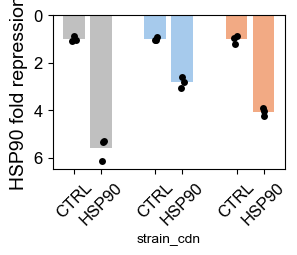

In [165]:
plt.figure(figsize=(3,2))

sns.stripplot(data=qpcr_HSP90_comp_df, x='strain_cdn', y='HSP90_fold_rep', native_scale=True, color='k')

plt.bar([1, 2 ,4,5, 7,8], [mean_list[x] for x in [0,3, 1,4, 2,5]], color = ['silver', 'silver', '#A6CAEC', '#A6CAEC', '#F2AA84', '#F2AA84'])

plt.ylabel('HSP90 fold repression', fontsize=14)
plt.ylim(6.5,0)
plt.yticks([0,2,4,6], fontsize=12)
plt.xticks([1, 2 ,4,5, 7,8], ['CTRL', 'HSP90', 'CTRL', 'HSP90', 'CTRL', 'HSP90'], fontsize=12, rotation=45)

plt.savefig('./figures/qPCR_three_backgrounds_revised.svg', dpi=300, format='svg')

In [166]:
mean_list_baseline_HSP90 = list(qpcr_HSP90_comp_df.groupby(['Strain', 'sgRNA'],sort=False)['deltaHSP90'].mean())
mean_list_baseline_HSP90

[0.749432985526667,
 0.5894381906331004,
 0.42777591442953283,
 3.2298901579994,
 2.085300332348234,
 2.452811259710866]

In [167]:
qpcr_HSP90_comp_df['HSP90_baseline_vs_wt'] = 1/(2**(qpcr_HSP90_comp_df['deltaHSP90'] - 0.749432985526667))
qpcr_HSP90_comp_df['HSP90_baseline_vs_wt']

0     0.960376
1     1.129715
2     0.921700
3     1.199402
4     1.082003
5     1.074723
6     1.039926
7     1.440871
8     1.302740
9     0.162663
10    0.187284
11    0.188857
12    0.362017
13    0.431633
14    0.397876
15    0.318092
16    0.309892
17    0.293720
Name: HSP90_baseline_vs_wt, dtype: float64

In [168]:
mean_list_baseline_HSP90 = list(qpcr_HSP90_comp_df.groupby(['Strain', 'sgRNA'],sort=False)['HSP90_baseline_vs_wt'].mean())
mean_list_baseline_HSP90

[1.003930517289516,
 1.1187092507405763,
 1.2611789909968179,
 0.17960151329219332,
 0.39717542374472087,
 0.30723455230262864]

In [169]:
stats.ttest_ind([0.960376, 1.129715, 0.921700], [1.199402, 1.082003, 1.074723], equal_var=False)

TtestResult(statistic=-1.5186418218331414, pvalue=0.21610770721554834, df=3.3794350700902167)

In [170]:
stats.ttest_ind([0.960376, 1.129715, 0.921700], [1.039926,  1.440871, 1.302740], equal_var=False)

TtestResult(statistic=-1.9223192910255917, pvalue=0.14773711158897376, df=3.085703348927501)

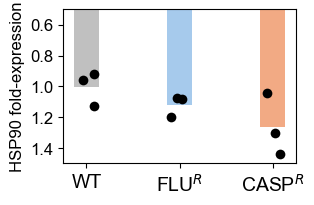

In [172]:
plt.figure(figsize=(3,2))

sns.stripplot(data=qpcr_HSP90_comp_df[qpcr_HSP90_comp_df['sgRNA']=='CTRL'], x='strain_cdn', y='HSP90_baseline_vs_wt', native_scale=True, color='k', size=7, dodge=True)

plt.ylabel('HSP90 fold-expression', fontsize=12)

plt.bar([1, 4 ,7], [mean_list_baseline_HSP90[x] for x in [0,1,2]], color = ['silver', '#A6CAEC', '#F2AA84'])

plt.ylim(1.5, 0.5)
plt.yticks(fontsize=12)
plt.xticks([1, 4, 7], ['WT', 'FLU$^{R}$', 'CASP$^{R}$'], fontsize=14)
plt.xlabel('')

plt.savefig('./figures/strains_HSP90_qpcr.svg', format='svg', dpi=300, bbox_inches='tight')
plt.savefig('./figures/strains_HSP90_qpcr.png', format='png', dpi=300, bbox_inches='tight')

In [ ]:
HSP90_comp_plate_ref = pd.read_excel('./Growth_curve_data/10_2025/HSP90 test in the 3 background strains/Growth curve/HSP90_diff_background_plate_map.xlsx', index_col=0)
HSP90_comp_plate_ref

## MRPL33 comparison

In [ ]:
MRPL33_comp_plate_ref = pd.read_excel('./Growth_curve_data/MRPL33_comp_plate_map.xlsx', index_col=0)
MRPL33_comp_plate_ref

In [ ]:
MRPL33_comp_data = pd.read_excel('./Growth_curve_data/raw_data_MRPL33_clin.xlsx', index_col=0).T
MRPL33_comp_data

In [ ]:
for well in MRPL33_comp_data.columns:
    plt.plot(MRPL33_comp_data[well])

In [ ]:
growth_rate_dict_MRPL33_comp = get_growth_rate_dict(MRPL33_comp_data)
get_AUC_dict_MRPL33_comp = get_AUC_dict(MRPL33_comp_data)

MRPL33_comp_plate_ref['growth_rate'] = pd.Series(growth_rate_dict_MRPL33_comp)
MRPL33_comp_plate_ref['AUC'] = pd.Series(get_AUC_dict_MRPL33_comp)

In [ ]:
MRPL33_comp_blanks = MRPL33_comp_plate_ref['strain']=='Blank'
MRPL33_comp_plate_ref[~MRPL33_comp_blanks]

In [ ]:
MRPL33_comp_blank_median = MRPL33_comp_plate_ref[MRPL33_comp_blanks]['AUC'].median()
MRPL33_comp_plate_ref['adjusted_AUC'] = MRPL33_comp_plate_ref['AUC']-MRPL33_comp_blank_median

MRPL33_comp_plate_ref

In [ ]:
MRPL33_comp_plate_ref.sgRNA_number.unique(), MRPL33_comp_plate_ref.background.unique()

In [ ]:
MRPL33_comp_err_plot_dict_of_dict = {}


index=0

for strain in ['CTRL', 'sgRNA_222', 'sgRNA_223']:
    for biorep in [1,2]:
        for background in ['WT', 'FLU', 'CASP']:
            val_dict = {}
            df_slice = MRPL33_comp_plate_ref[(MRPL33_comp_plate_ref['sgRNA_number']==strain)&(MRPL33_comp_plate_ref['biological_replicate']==biorep)&(MRPL33_comp_plate_ref['background']==background)]
    
            auc_vals = list(df_slice['adjusted_AUC'])
    
            val_dict['strain'] = strain+''+str(biorep)
            val_dict['background'] = background
            val_dict['mean'] = np.mean(auc_vals)
            val_dict['err_95'] = np.mean(auc_vals) - stats.t.interval(0.95, len(auc_vals)-1, loc=np.mean(auc_vals), scale=stats.sem(auc_vals))[0]
    
            MRPL33_comp_err_plot_dict_of_dict[index] = val_dict
            index+=1

MRPL33_comp_err_plot_dict_of_dict

In [ ]:
plt.figure(figsize=(3.75,3))
ax = plt.subplot(111)


plot_index=1

color_list = ['k', 'k', '#F7BC04', '#F7BC04','#492690','#492690']*3

key_order = [0,  3,  6,  9,  12, 15,
             1,  4,  7,  10, 13, 16,
             2,  5,  8,  11, 14, 17]


for x in range(0,18):
    if key_order[x]%2==0:
        plt.scatter(plot_index, MRPL33_comp_err_plot_dict_of_dict[key_order[x]]['mean'], color=color_list[x], s=25, zorder=9)
        plt.errorbar(plot_index, MRPL33_comp_err_plot_dict_of_dict[key_order[x]]['mean'], MRPL33_comp_err_plot_dict_of_dict[key_order[x]]['err_95'], 
                     color=color_list[x], elinewidth=2, capsize=3, capthick=2, zorder=9)

    else:
        plt.scatter(plot_index, MRPL33_comp_err_plot_dict_of_dict[key_order[x]]['mean'], color=color_list[x], s=25, zorder=9)
        plt.errorbar(plot_index, MRPL33_comp_err_plot_dict_of_dict[key_order[x]]['mean'], MRPL33_comp_err_plot_dict_of_dict[key_order[x]]['err_95'], 
                     color=color_list[x], elinewidth=2, capsize=3, capthick=2, zorder=9)
    plot_index+=1

    if x%2:
        if key_order[x]%2==0:
            mean = np.mean([MRPL33_comp_err_plot_dict_of_dict[key_order[x]]['mean'], MRPL33_comp_err_plot_dict_of_dict[key_order[x-1]]['mean']])
            plt.plot([plot_index-2.75, plot_index-0.25], [mean, mean], color='grey', lw=2.5)
            print(plot_index)

        else:
            mean = np.mean([MRPL33_comp_err_plot_dict_of_dict[key_order[x]]['mean'], MRPL33_comp_err_plot_dict_of_dict[key_order[x-1]]['mean']])
            plt.plot([plot_index-2.75, plot_index-0.25], [mean, mean], color='grey', lw=2.5)

        if x >1:
            wt_vals = [MRPL33_comp_err_plot_dict_of_dict[0]['mean'], MRPL33_comp_err_plot_dict_of_dict[1]['mean']]
            test_val = [MRPL33_comp_err_plot_dict_of_dict[x]['mean'], MRPL33_comp_err_plot_dict_of_dict[x-1]['mean']]
            #print(wt_vals, test_val)
            #print(scipy.stats.ttest_ind(wt_vals, test_val, equal_var=False)[1])

            stat, pval = scipy.stats.ttest_ind(wt_vals, test_val, equal_var=False)
            if pval < 0.05:
                #print(test_val, pval)
                plt.plot([plot_index-1.5], [mean+1.25], marker='$*$', color='k', ms=5)
        
        print(x)
        plot_index+=2


ax.add_patch(plt.Rectangle((-1,12),37/3, 1,facecolor='silver',
                              clip_on=False,linewidth = 0))

plt.text(x=((37/6)-1), y=12.15, s='WT', fontsize=12, ha='center')

ax.add_patch(plt.Rectangle(((37/3-1),12),37/3, 1,facecolor='#A6CAEC',
                              clip_on=False,linewidth = 0))

plt.text(x=((1.5*37/3)-1), y=12.15, s='FLU$^R$', fontsize=12, ha='center')


ax.add_patch(plt.Rectangle(((2*37/3-1),12),37/3, 1,facecolor='#F2AA84',
                              clip_on=False,linewidth = 0))

plt.text(x=((2.5*37/3)-1), y=12.15, s='CASP$^R$', fontsize=12, ha='center')

plt.ylabel('AUC', fontsize=14)
plt.xlabel('Strain', fontsize=14)
plt.xticks([1.5, 5.5, 9.5, 13.5, 17.5, 21.5, 25.5, 29.5, 33.5],['WT', '2','3']*3, fontsize=12)
plt.yticks(fontsize=12)
plt.xlim(-1,36)
plt.ylim(0,12)

plt.savefig('./figures/MRPL33_background_validations.svg', format='svg', dpi=300)

## ASK1 comparison

In [113]:
ASK1_comp_plate_ref = pd.read_excel('./Growth_curve_data/ASK1_comp_plate_map.xlsx', index_col=0)
ASK1_comp_plate_ref

,strain,sgRNA_number,background,medium,biological_replicate,technical_replicate
well,,,,,,
A1,Blank,NaN,NaN,YPD,NaN,NaN
A2,Blank,NaN,NaN,YPD,NaN,NaN
A3,Blank,NaN,NaN,YPD,NaN,NaN
A4,Blank,NaN,NaN,YPD,NaN,NaN
A5,Blank,NaN,NaN,YPD,NaN,NaN
...,...,...,...,...,...,...
H8,Blank,NaN,NaN,YPD,NaN,NaN
H9,Blank,NaN,NaN,YPD,NaN,NaN
H10,Blank,NaN,NaN,YPD,NaN,NaN


In [114]:
ASK1_comp_data = pd.read_excel('./Growth_curve_data/raw_data_ASK1_clin.xlsx', index_col=0).T
ASK1_comp_data

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,H3,H4,H5,H6,H7,H8,H9,H10,H11,H12
0.000000,0.1015,0.1016,0.1015,0.1022,0.1013,0.1015,0.1017,0.1015,0.1021,0.1028,...,0.1032,0.1027,0.1005,0.1009,0.1007,0.1017,0.1010,0.1020,0.1021,0.1019
0.333333,0.1011,0.1012,0.1011,0.1024,0.1010,0.1013,0.1014,0.1012,0.1017,0.1023,...,0.1029,0.1023,0.1001,0.1004,0.1003,0.1012,0.1005,0.1015,0.1016,0.1015
0.666667,0.1011,0.1011,0.1011,0.1015,0.1010,0.1012,0.1014,0.1012,0.1017,0.1024,...,0.1032,0.1024,0.1003,0.1006,0.1005,0.1013,0.1007,0.1017,0.1018,0.1017
1.000000,0.1011,0.1011,0.1011,0.1019,0.1010,0.1012,0.1014,0.1012,0.1017,0.1024,...,0.1037,0.1031,0.1009,0.1012,0.1011,0.1020,0.1013,0.1023,0.1024,0.1023
1.333333,0.1012,0.1012,0.1011,0.1010,0.1010,0.1012,0.1014,0.1012,0.1017,0.1024,...,0.1042,0.1034,0.1012,0.1015,0.1014,0.1023,0.1016,0.1027,0.1027,0.1027
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19.666667,0.1003,0.1002,0.1002,0.1012,0.1000,0.1002,0.1003,0.1002,0.1007,0.1013,...,0.1030,0.1021,0.1000,0.1003,0.1002,0.1007,0.1004,0.1017,0.1014,0.1014
20.000000,0.1003,0.1002,0.1002,0.1000,0.0999,0.1002,0.1003,0.1002,0.1008,0.1013,...,0.1026,0.1018,0.0997,0.1000,0.0999,0.1004,0.1000,0.1011,0.1011,0.1011
20.333333,0.1003,0.1003,0.1003,0.0999,0.1000,0.1003,0.1004,0.1003,0.1008,0.1014,...,0.1030,0.1021,0.1000,0.1003,0.1002,0.1007,0.1004,0.1014,0.1014,0.1013
20.666667,0.1003,0.1002,0.1002,0.0998,0.1000,0.1002,0.1004,0.1003,0.1008,0.1014,...,0.1030,0.1022,0.1000,0.1004,0.1002,0.1008,0.1004,0.1015,0.1015,0.1013


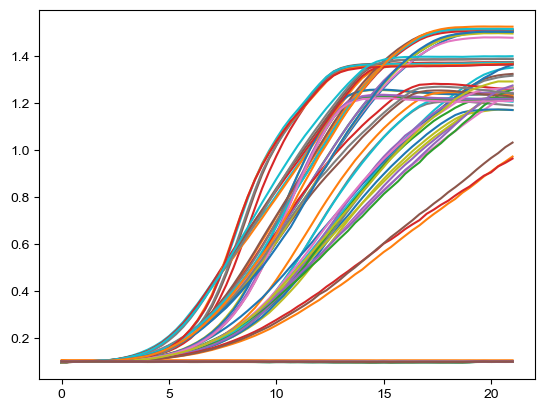

In [115]:
for well in ASK1_comp_data.columns:
    plt.plot(ASK1_comp_data[well])

In [116]:
growth_rate_dict_ASK1_comp = get_growth_rate_dict(ASK1_comp_data)
get_AUC_dict_ASK1_comp = get_AUC_dict(ASK1_comp_data)

ASK1_comp_plate_ref['growth_rate'] = pd.Series(growth_rate_dict_ASK1_comp)
ASK1_comp_plate_ref['AUC'] = pd.Series(get_AUC_dict_ASK1_comp)

In [117]:
ASK1_comp_blanks = ASK1_comp_plate_ref['strain']=='Blank'
ASK1_comp_plate_ref[~ASK1_comp_blanks]

,strain,sgRNA_number,background,medium,biological_replicate,technical_replicate,growth_rate,AUC
well,,,,,,,,
B2,FRS 584,CTRL,WT,YPD,1.0,1.0,0.2490,12.804367
B3,FRS 843,sgRNA_274,WT,YPD,1.0,1.0,0.1032,7.175700
B4,FRS 846,sgRNA_275,WT,YPD,1.0,1.0,0.1209,7.781733
B5,FRS 947,CTRL,FLU,YPD,1.0,1.0,0.2097,10.567150
B6,FRS 844,sgRNA_274,FLU,YPD,1.0,1.0,0.1482,8.434200
B7,FRS 847,sgRNA_275,FLU,YPD,1.0,1.0,0.1173,7.214967
B8,FRS 948,CTRL,CASP,YPD,1.0,1.0,0.1335,12.375117
B9,FRS 845,sgRNA_274,CASP,YPD,1.0,1.0,0.1404,10.708767
B10,FRS 848,sgRNA_275,CASP,YPD,1.0,1.0,0.1491,11.753917


In [118]:
ASK1_comp_blank_median = ASK1_comp_plate_ref[ASK1_comp_blanks]['AUC'].median()
ASK1_comp_plate_ref['adjusted_AUC'] = ASK1_comp_plate_ref['AUC']-ASK1_comp_blank_median

ASK1_comp_plate_ref

,strain,sgRNA_number,background,medium,biological_replicate,technical_replicate,growth_rate,AUC,adjusted_AUC
well,,,,,,,,,
A1,Blank,NaN,NaN,YPD,NaN,NaN,0.0003,1.780717,0.000317
A2,Blank,NaN,NaN,YPD,NaN,NaN,0.0003,1.780267,-0.000133
A3,Blank,NaN,NaN,YPD,NaN,NaN,0.0003,1.780167,-0.000233
A4,Blank,NaN,NaN,YPD,NaN,NaN,0.0036,1.781367,0.000967
A5,Blank,NaN,NaN,YPD,NaN,NaN,0.0003,1.774350,-0.006050
...,...,...,...,...,...,...,...,...,...
H8,Blank,NaN,NaN,YPD,NaN,NaN,0.0009,1.774350,-0.006050
H9,Blank,NaN,NaN,YPD,NaN,NaN,0.0009,1.764783,-0.015617
H10,Blank,NaN,NaN,YPD,NaN,NaN,0.0009,1.782833,0.002433


In [119]:
ASK1_comp_plate_ref.sgRNA_number.unique(), ASK1_comp_plate_ref.background.unique()

(array([nan, 'CTRL', 'sgRNA_274', 'sgRNA_275'], dtype=object),
 array([nan, 'WT', 'FLU', 'CASP'], dtype=object))

In [120]:
ASK1_comp_err_plot_dict_of_dict = {}


index=0

for strain in ['CTRL', 'sgRNA_274', 'sgRNA_275']:
    for biorep in [1,2]:
        for background in ['WT', 'FLU', 'CASP']:
            val_dict = {}
            df_slice = ASK1_comp_plate_ref[(ASK1_comp_plate_ref['sgRNA_number']==strain)&(ASK1_comp_plate_ref['biological_replicate']==biorep)&(ASK1_comp_plate_ref['background']==background)]
            
            auc_vals = list(df_slice['adjusted_AUC'])
    
            val_dict['strain'] = strain+''+str(biorep)
            val_dict['background'] = background
            val_dict['mean'] = np.mean(auc_vals)
            val_dict['err_95'] = np.mean(auc_vals) - stats.t.interval(0.95, len(auc_vals)-1, loc=np.mean(auc_vals), scale=stats.sem(auc_vals))[0]
    
            ASK1_comp_err_plot_dict_of_dict[index] = val_dict
            index+=1

ASK1_comp_err_plot_dict_of_dict

{0: {'strain': 'CTRL1',
  'background': 'WT',
  'mean': 11.186605579944127,
  'err_95': 0.3527376833878595},
 1: {'strain': 'CTRL1',
  'background': 'FLU',
  'mean': 9.000572222595418,
  'err_95': 0.46044480305539714},
 2: {'strain': 'CTRL1',
  'background': 'CASP',
  'mean': 10.586494468359488,
  'err_95': 0.24582157003449545},
 3: {'strain': 'CTRL2',
  'background': 'WT',
  'mean': 11.470022267972437,
  'err_95': 0.1146237574514597},
 4: {'strain': 'CTRL2',
  'background': 'FLU',
  'mean': 8.76580000730853,
  'err_95': 0.1527520154976134},
 5: {'strain': 'CTRL2',
  'background': 'CASP',
  'mean': 10.82063332924413,
  'err_95': 0.35965138151001597},
 6: {'strain': 'sgRNA_2741',
  'background': 'WT',
  'mean': 5.456388887224928,
  'err_95': 0.3795784828484683},
 7: {'strain': 'sgRNA_2741',
  'background': 'FLU',
  'mean': 6.80336669356459,
  'err_95': 0.6235620232404431},
 8: {'strain': 'sgRNA_2741',
  'background': 'CASP',
  'mean': 9.127950050557658,
  'err_95': 0.43077342015077136},

1
3
5
15
7
19
9
23
11
13
15
17


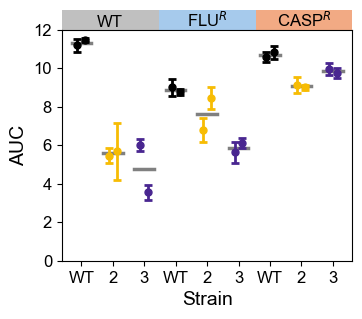

In [121]:
plt.figure(figsize=(3.75,3))
ax = plt.subplot(111)


plot_index=1

color_list = ['k', 'k', '#F7BC04', '#F7BC04','#492690','#492690']*3

key_order = [0,  3,  6,  9,  12, 15,
             1,  4,  7,  10, 13, 16,
             2,  5,  8,  11, 14, 17]


for x in range(0,18):
    if key_order[x]%2==0:
        plt.scatter(plot_index, ASK1_comp_err_plot_dict_of_dict[key_order[x]]['mean'], color=color_list[x], s=25, zorder=9)
        plt.errorbar(plot_index, ASK1_comp_err_plot_dict_of_dict[key_order[x]]['mean'], ASK1_comp_err_plot_dict_of_dict[key_order[x]]['err_95'], 
                     color=color_list[x], elinewidth=2, capsize=3, capthick=2, zorder=9)

    else:
        plt.scatter(plot_index, ASK1_comp_err_plot_dict_of_dict[key_order[x]]['mean'], color=color_list[x], s=25, zorder=9)
        plt.errorbar(plot_index, ASK1_comp_err_plot_dict_of_dict[key_order[x]]['mean'], ASK1_comp_err_plot_dict_of_dict[key_order[x]]['err_95'], 
                     color=color_list[x], elinewidth=2, capsize=3, capthick=2, zorder=9)
    plot_index+=1

    if x%2:
        if key_order[x]%2==0:
            mean = np.mean([ASK1_comp_err_plot_dict_of_dict[key_order[x]]['mean'], ASK1_comp_err_plot_dict_of_dict[key_order[x-1]]['mean']])
            plt.plot([plot_index-2.75, plot_index-0.25], [mean, mean], color='grey', lw=2.5)
            print(plot_index)

        else:
            mean = np.mean([ASK1_comp_err_plot_dict_of_dict[key_order[x]]['mean'], ASK1_comp_err_plot_dict_of_dict[key_order[x-1]]['mean']])
            plt.plot([plot_index-2.75, plot_index-0.25], [mean, mean], color='grey', lw=2.5)

        if x >1:
            wt_vals = [ASK1_comp_err_plot_dict_of_dict[0]['mean'], ASK1_comp_err_plot_dict_of_dict[1]['mean']]
            test_val = [ASK1_comp_err_plot_dict_of_dict[x]['mean'], ASK1_comp_err_plot_dict_of_dict[x-1]['mean']]
            #print(wt_vals, test_val)
            #print(scipy.stats.ttest_ind(wt_vals, test_val, equal_var=False)[1])

            stat, pval = scipy.stats.ttest_ind(wt_vals, test_val, equal_var=False)
            if pval < 0.05:
                #print(test_val, pval)
                plt.plot([plot_index-1.5], [mean+1.25], marker='$*$', color='k', ms=5)
        
        print(x)
        plot_index+=2


ax.add_patch(plt.Rectangle((-1,12),37/3, 1,facecolor='silver',
                              clip_on=False,linewidth = 0))

plt.text(x=((37/6)-1), y=12.15, s='WT', fontsize=12, ha='center')

ax.add_patch(plt.Rectangle(((37/3-1),12),37/3, 1,facecolor='#A6CAEC',
                              clip_on=False,linewidth = 0))

plt.text(x=((1.5*37/3)-1), y=12.15, s='FLU$^R$', fontsize=12, ha='center')


ax.add_patch(plt.Rectangle(((2*37/3-1),12),37/3, 1,facecolor='#F2AA84',
                              clip_on=False,linewidth = 0))

plt.text(x=((2.5*37/3)-1), y=12.15, s='CASP$^R$', fontsize=12, ha='center')

plt.ylabel('AUC', fontsize=14)
plt.xlabel('Strain', fontsize=14)
plt.xticks([1.5, 5.5, 9.5, 13.5, 17.5, 21.5, 25.5, 29.5, 33.5],['WT', '2','3']*3, fontsize=12)
plt.yticks(fontsize=12)
plt.xlim(-1,36)
plt.ylim(0,12)

plt.savefig('./figures/ASK1_background_validations.svg', format='svg', dpi=300)